# Unbounded-alpha single-shot analysis

Adapted from the broad all-dynamics analysis notebook. Reads `results/alpha_u_ss` directly from the run manifest and cache.

# Analysis and plotting: broad all-dynamics, multi-topology benchmark

This notebook performs **no model training**.

It reconstructs the complete result tables directly from the persistent cache
written by:

`alpha_u_ss.ipynb`

You can therefore change every figure, font, label, axis, style, or export
format without rerunning a single learned trajectory.

## Plot-style toggle

At the top of the notebook choose:

```python
PLOT_STYLE = "paper_bw"
```

for simple publication-oriented figures designed to survive grayscale /
black-and-white printing, or:

```python
PLOT_STYLE = "explore"
```

for the more colorful figures used while exploring results.

The paper mode uses simple sans-serif fonts, grayscale fills, hatches,
linestyles, and marker differences rather than relying on color alone.

Both PNG and vector PDF export can be enabled independently.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, t as student_t

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 280)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find repository root containing opinion_dynamics/."
    )


REPO_ROOT = find_repo_root()

RESULTS_DIR = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
    / "alpha_u_ss"
)
MANIFEST_PATH = RESULTS_DIR / "RUN_MANIFEST.json"

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        f"Run manifest not found: {MANIFEST_PATH}\n"
        "Run the computation notebook/launcher first."
    )

RUN_MANIFEST = json.loads(
    MANIFEST_PATH.read_text(encoding="utf-8")
)

CACHE_ROOT = Path(RUN_MANIFEST["cache_root"])
LEARNING_SEEDS = [
    int(value)
    for value in RUN_MANIFEST["learning_seeds"]
]

print("Results dir:", RESULTS_DIR)
print("Cache root:", CACHE_ROOT)
print("Git commit used for experiment:", RUN_MANIFEST["git_commit"])
print("Expected environments:", RUN_MANIFEST["n_environments"])
print(
    "Expected learned runs:",
    RUN_MANIFEST["n_learned_runs_expected"],
)


C:\Users\Chainsword\AppData\Local\Temp\ipykernel_20000\454986127.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Results dir: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\alpha_u_ss
Cache root: D:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\alpha_u_ss
Git commit used for experiment: 1c638e1
Expected environments: 195
Expected learned runs: 585


## Plot style and export settings


In [2]:
# ---------------------------------------------------------------------------
# Change only this value to remake every figure for a different purpose.
# ---------------------------------------------------------------------------
PLOT_STYLE = "paper_bw"   # "paper_bw" or "explore"

SAVE_PNG = True
SAVE_PDF = True

if PLOT_STYLE not in {"paper_bw", "explore"}:
    raise ValueError(PLOT_STYLE)

PLOT_DIR = RESULTS_DIR / f"plots_{PLOT_STYLE}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def apply_plot_style(style: str) -> None:
    mpl.rcdefaults()

    common = {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "DejaVu Sans",
            "Arial",
            "Liberation Sans",
        ],
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }

    if style == "paper_bw":
        common.update(
            {
                "axes.grid": False,
                "axes.edgecolor": "0.15",
                "text.color": "0.1",
                "axes.labelcolor": "0.1",
                "xtick.color": "0.1",
                "ytick.color": "0.1",
            }
        )
    else:
        common.update(
            {
                "axes.grid": True,
                "grid.alpha": 0.22,
            }
        )

    mpl.rcParams.update(common)


apply_plot_style(PLOT_STYLE)

# Every policy remains distinguishable in black-and-white because marker,
# linestyle, and hatch differ even when colors disappear.
if PLOT_STYLE == "paper_bw":
    POLICY_STYLE = {
        "no control": {
            "color": "0.80",
            "marker": "x",
            "linestyle": ":",
            "hatch": "..",
        },
        "uniform": {
            "color": "0.58",
            "marker": "s",
            "linestyle": "--",
            "hatch": "//",
        },
        "learned": {
            "color": "0.18",
            "marker": "o",
            "linestyle": "-",
            "hatch": "xx",
        },
        "true graph": {
            "color": "0.38",
            "marker": "^",
            "linestyle": "-.",
            "hatch": "\\\\",
        },
    }
else:
    POLICY_STYLE = {
        "no control": {
            "color": "#7f7f7f",
            "marker": "x",
            "linestyle": ":",
            "hatch": "..",
        },
        "uniform": {
            "color": "#d08c28",
            "marker": "s",
            "linestyle": "--",
            "hatch": "//",
        },
        "learned": {
            "color": "#2b6cb0",
            "marker": "o",
            "linestyle": "-",
            "hatch": "xx",
        },
        "true graph": {
            "color": "#3b8f55",
            "marker": "^",
            "linestyle": "-.",
            "hatch": "\\\\",
        },
    }

DYNAMICS_LABELS = {
    "laplacian": "Linear",
    "coca": "COCA",
    "hegselmannkrause": "HK",
    "friedkinjohnsen": "FJ",
    "nonlinearinfluence": "Nonlinear",
    "repulsion": "Repulsion",
}

DYNAMICS_ORDER = [
    "laplacian",
    "coca",
    "hegselmannkrause",
    "friedkinjohnsen",
    "nonlinearinfluence",
    "repulsion",
]

FAMILY_LABELS = {
    "ring_bridge": "Ring bridge",
    "paired_bridge": "Paired bridge",
    "dense_weak_bridge": "Dense weak bridge",
    "asymmetric_broadcast": "Asymmetric broadcast",
    "dual_broadcast": "Dual broadcast",
    "split_broadcast": "Split broadcast",
}

def save_figure(fig: plt.Figure, stem: str) -> None:
    if SAVE_PNG:
        fig.savefig(PLOT_DIR / f"{stem}.png")
    if SAVE_PDF:
        fig.savefig(PLOT_DIR / f"{stem}.pdf")


print("Plot style:", PLOT_STYLE)
print("Plot output:", PLOT_DIR)


Plot style: paper_bw
Plot output: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\alpha_u_ss\plots_paper_bw


## Load and validate the persistent cache


In [3]:
def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


baseline_rows = []
learned_rows = []
missing = []

ENV_INDEX = {
    row["environment_id"]: row
    for row in RUN_MANIFEST["environments"]
}

for env_meta in RUN_MANIFEST["environments"]:
    environment_id = env_meta["environment_id"]
    cache_dir = Path(env_meta["cache_dir"])

    baseline_summary = cache_dir / "baseline_summary.json"

    if not baseline_summary.exists():
        missing.append((environment_id, "baseline"))
        continue

    baseline_rows.extend(read_json(baseline_summary))

    learned_root = cache_dir / "learned"

    for learning_seed in LEARNING_SEEDS:
        candidates = (
            list(
                learned_root.glob(
                    f"seed_{learning_seed:02d}_*/summary.json"
                )
            )
            if learned_root.exists()
            else []
        )

        if len(candidates) != 1:
            missing.append(
                (
                    environment_id,
                    f"learned_seed_{learning_seed}",
                )
            )
            continue

        learned_rows.append(read_json(candidates[0]))

if missing:
    print("First missing entries:", missing[:20])
    raise RuntimeError(
        f"Broad experiment cache incomplete: {len(missing)} missing entries."
    )

baseline_df = pd.DataFrame(baseline_rows)
learned_df = pd.DataFrame(learned_rows)

expected_envs = int(RUN_MANIFEST["n_environments"])
expected_learned = int(
    RUN_MANIFEST["n_learned_runs_expected"]
)

assert len(baseline_df) == expected_envs * 3
assert len(learned_df) == expected_learned

assert not baseline_df.duplicated(
    subset=["environment_id", "policy"]
).any()

assert not learned_df.duplicated(
    subset=["environment_id", "learning_seed"]
).any()

print("Cache validation passed.")
print("Baseline rows:", len(baseline_df))
print("Learned rows:", len(learned_df))

display(
    learned_df.groupby(
        ["scenario_class", "dynamics"],
        as_index=False,
    ).size()
)

Cache validation passed.
Baseline rows: 585
Learned rows: 585


,scenario_class,dynamics,size
0,structured_mechanism,friedkinjohnsen,45
1,structured_mechanism,hegselmannkrause,45
2,structured_mechanism,nonlinearinfluence,45
3,unstructured_random,coca,75
4,unstructured_random,friedkinjohnsen,75
5,unstructured_random,hegselmannkrause,75
6,unstructured_random,laplacian,75
7,unstructured_random,nonlinearinfluence,75
8,unstructured_random,repulsion,75


## Reconstruct environment-level paired results


In [4]:
learned_env = (
    learned_df.groupby(
        [
            "environment_id",
            "scenario_class",
            "family",
            "dynamics",
        ],
        as_index=False,
    )
    .agg(
        learned_final_mean=(
            "final_mean",
            "mean",
        ),
        learned_final_mean_seed_std=(
            "final_mean",
            "std",
        ),
        learned_mean_over_campaigns=(
            "mean_over_campaigns",
            "mean",
        ),
        learned_path_seed_std=(
            "mean_over_campaigns",
            "std",
        ),
        final_fit_model_over_identity=(
            "final_fit_model_over_identity",
            "mean",
        ),
    )
)

uniform_env = (
    baseline_df[
        baseline_df["policy"] == "uniform"
    ][
        [
            "environment_id",
            "final_mean",
            "mean_over_campaigns",
        ]
    ]
    .rename(
        columns={
            "final_mean": "uniform_final_mean",
            "mean_over_campaigns": "uniform_mean_over_campaigns",
        }
    )
)

oracle_env = (
    baseline_df[
        baseline_df["policy"] == "true_graph"
    ][
        [
            "environment_id",
            "final_mean",
            "mean_over_campaigns",
        ]
    ]
    .rename(
        columns={
            "final_mean": "oracle_final_mean",
            "mean_over_campaigns": "oracle_mean_over_campaigns",
        }
    )
)

no_control_env = (
    baseline_df[
        baseline_df["policy"] == "no_control"
    ][
        [
            "environment_id",
            "final_mean",
            "mean_over_campaigns",
        ]
    ]
    .rename(
        columns={
            "final_mean": "no_control_final_mean",
            "mean_over_campaigns": "no_control_mean_over_campaigns",
        }
    )
)

env_level_df = (
    learned_env
    .merge(
        uniform_env,
        on="environment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        oracle_env,
        on="environment_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        no_control_env,
        on="environment_id",
        how="left",
        validate="one_to_one",
    )
)


# Recover the crossed generic-design factors from the stable environment IDs.
# Structured environments do not have topology/opinion seed factors and remain NaN.
env_level_df["topology_seed"] = pd.to_numeric(
    env_level_df["environment_id"].str.extract(r"__topo(\d+)__")[0],
    errors="coerce",
)
env_level_df["opinion_seed"] = pd.to_numeric(
    env_level_df["environment_id"].str.extract(r"__x(\d+)$")[0],
    errors="coerce",
)
env_level_df["environment_seed"] = pd.to_numeric(
    env_level_df["environment_id"].str.extract(r"__env(\d+)$")[0],
    errors="coerce",
)
env_level_df["true_graph_final_mean"] = env_level_df["oracle_final_mean"]
env_level_df["true_graph_mean_over_campaigns"] = env_level_df["oracle_mean_over_campaigns"]

env_level_df["learned_gap_final"] = (
    env_level_df["learned_final_mean"]
    - env_level_df["uniform_final_mean"]
)
env_level_df["learned_gap_path"] = (
    env_level_df["learned_mean_over_campaigns"]
    - env_level_df["uniform_mean_over_campaigns"]
)
env_level_df["oracle_gap_final"] = (
    env_level_df["oracle_final_mean"]
    - env_level_df["uniform_final_mean"]
)
env_level_df["oracle_gap_path"] = (
    env_level_df["oracle_mean_over_campaigns"]
    - env_level_df["uniform_mean_over_campaigns"]
)

env_level_df["learned_minus_true_graph_final"] = (
    env_level_df["learned_final_mean"]
    - env_level_df["true_graph_final_mean"]
)

env_level_df["oracle_advantage_recovered"] = np.where(
    np.abs(env_level_df["oracle_gap_final"]) > 1e-12,
    (
        env_level_df["learned_gap_final"]
        / env_level_df["oracle_gap_final"]
    ),
    np.nan,
)

baseline_df.to_csv(
    RESULTS_DIR / "baseline_results.csv",
    index=False,
)
learned_df.to_csv(
    RESULTS_DIR / "learned_seed_results.csv",
    index=False,
)
env_level_df.to_csv(
    RESULTS_DIR / "environment_level_results.csv",
    index=False,
)

display(env_level_df.head().round(5))


,environment_id,scenario_class,family,dynamics,learned_final_mean,learned_final_mean_seed_std,learned_mean_over_campaigns,learned_path_seed_std,final_fit_model_over_identity,uniform_final_mean,uniform_mean_over_campaigns,oracle_final_mean,oracle_mean_over_campaigns,no_control_final_mean,no_control_mean_over_campaigns,topology_seed,opinion_seed,environment_seed,true_graph_final_mean,true_graph_mean_over_campaigns,learned_gap_final,learned_gap_path,oracle_gap_final,oracle_gap_path,learned_minus_true_graph_final,oracle_advantage_recovered
0,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.61726,0.00370,0.53399,0.00202,0.06473,0.41569,0.38387,0.62371,0.53865,0.31300,0.31846,NaN,NaN,0.0,0.62371,0.53865,0.20157,0.15012,0.20802,0.15478,-0.00645,0.96899
1,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.61663,0.00037,0.52887,0.00286,0.06416,0.41041,0.37842,0.62004,0.53436,0.30678,0.31241,NaN,NaN,1.0,0.62004,0.53436,0.20622,0.15046,0.20963,0.15594,-0.00341,0.98373
2,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.62061,0.00296,0.53545,0.00272,0.06431,0.41653,0.38478,0.62333,0.53855,0.31397,0.31946,NaN,NaN,2.0,0.62333,0.53855,0.20408,0.15068,0.20680,0.15378,-0.00272,0.98686
3,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.62167,0.00224,0.53486,0.00320,0.06493,0.41642,0.38464,0.62452,0.53953,0.31385,0.31931,NaN,NaN,3.0,0.62452,0.53953,0.20526,0.15022,0.20811,0.15489,-0.00285,0.98631
4,structured__friedkinjohnsen__asymmetric_broadc...,structured_mechanism,asymmetric_broadcast,friedkinjohnsen,0.62207,0.00034,0.53540,0.00276,0.06396,0.41388,0.38197,0.62227,0.53699,0.31087,0.31635,NaN,NaN,4.0,0.62227,0.53699,0.20819,0.15343,0.20838,0.15503,-0.00019,0.99907


## Head-to-head metrics


In [5]:
def student_t_mean_ci(
    values: np.ndarray,
    confidence: float = 0.95,
) -> tuple[float, float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan

    mean = float(values.mean())
    if n == 1:
        return mean, np.nan, np.nan

    alpha = 1.0 - confidence
    critical = float(student_t.ppf(1.0 - alpha / 2.0, df=n - 1))
    half = critical * float(values.std(ddof=1)) / np.sqrt(n)
    return mean, mean - half, mean + half


def mean_ci95(values: np.ndarray) -> tuple[float, float]:
    """Legacy convenience wrapper, now using Student-t rather than 1.96."""
    mean, low, high = student_t_mean_ci(values)
    if not np.isfinite(low) or not np.isfinite(high):
        return mean, np.nan
    return mean, max(mean - low, high - mean)


def crossed_bootstrap_ci(
    group: pd.DataFrame,
    value_col: str,
    *,
    n_boot: int = 20_000,
    confidence: float = 0.95,
    seed: int = 20260817,
) -> tuple[float, float, float]:
    """Two-factor bootstrap for the complete topology-seed x opinion-seed design."""
    pivot = group.pivot(index="topology_seed", columns="opinion_seed", values=value_col)
    if pivot.isna().any().any():
        raise ValueError(f"Crossed bootstrap requires a complete design for {value_col}")

    matrix = pivot.to_numpy(dtype=float)
    n_rows, n_cols = matrix.shape
    rng = np.random.default_rng(seed)
    row_draws = rng.integers(0, n_rows, size=(n_boot, n_rows))
    col_draws = rng.integers(0, n_cols, size=(n_boot, n_cols))

    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        boot[b] = matrix[np.ix_(row_draws[b], col_draws[b])].mean()

    alpha = 1.0 - confidence
    low, high = np.quantile(boot, [alpha / 2.0, 1.0 - alpha / 2.0])
    return float(matrix.mean()), float(low), float(high)


def mean_ci_for_group(
    group: pd.DataFrame,
    value_col: str,
) -> tuple[float, float, float, str]:
    is_crossed_generic = (
        len(group) == 25
        and group["scenario_class"].eq("unstructured_random").all()
        and group["topology_seed"].nunique() == 5
        and group["opinion_seed"].nunique() == 5
    )
    if is_crossed_generic:
        mean, low, high = crossed_bootstrap_ci(group, value_col)
        return mean, low, high, "crossed bootstrap (topology x opinion)"

    mean, low, high = student_t_mean_ci(group[value_col].to_numpy())
    return mean, low, high, "Student-t over environments"


def summarize_group(group: pd.DataFrame) -> dict[str, Any]:
    final_mean, final_low, final_high, ci_method = mean_ci_for_group(
        group, "learned_gap_final"
    )
    path_mean, path_low, path_high, _ = mean_ci_for_group(
        group, "learned_gap_path"
    )
    true_mean, true_low, true_high, _ = mean_ci_for_group(
        group, "learned_minus_true_graph_final"
    )

    # Kept only as a diagnostic for backwards-compatible CSVs; it is not used
    # as a primary paper metric because the denominator can be small or change sign.
    recovery_mean, recovery_low, recovery_high = student_t_mean_ci(
        group["oracle_advantage_recovered"].to_numpy()
    )

    seed_subset = learned_df[
        learned_df["environment_id"].isin(group["environment_id"])
    ].merge(
        uniform_env,
        on="environment_id",
        how="left",
    )
    seed_gaps = seed_subset["final_mean"] - seed_subset["uniform_final_mean"]

    return {
        "n_environments": int(len(group)),
        "n_learning_runs": int(len(seed_subset)),
        "ci_method": ci_method,

        "learned_minus_uniform_final_mean": final_mean,
        "learned_minus_uniform_final_ci_low": final_low,
        "learned_minus_uniform_final_ci_high": final_high,
        "final_ci95_half": max(final_mean - final_low, final_high - final_mean),

        "learned_minus_uniform_path_mean": path_mean,
        "learned_minus_uniform_path_ci_low": path_low,
        "learned_minus_uniform_path_ci_high": path_high,
        "path_ci95_half": max(path_mean - path_low, path_high - path_mean),

        "learned_minus_true_graph_final_mean": true_mean,
        "learned_minus_true_graph_final_ci_low": true_low,
        "learned_minus_true_graph_final_ci_high": true_high,

        "environment_win_rate": float((group["learned_gap_final"] > 0).mean()),
        "environment_win_rate_vs_true_graph": float(
            (group["learned_minus_true_graph_final"] > 0).mean()
        ),
        "seed_run_win_rate": float((seed_gaps > 0).mean()),

        "oracle_gap_final_mean": float(group["oracle_gap_final"].mean()),
        "oracle_advantage_recovered_mean": recovery_mean,
        "recovery_ci95_half": max(
            recovery_mean - recovery_low,
            recovery_high - recovery_mean,
        ),

        "mean_learning_seed_std_final": float(
            group["learned_final_mean_seed_std"].mean()
        ),
        "mean_final_fit_model_over_identity": float(
            group["final_fit_model_over_identity"].mean()
        ),
    }


scenario_summary_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"],
    sort=False,
):
    scenario_summary_rows.append(
        {
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            **summarize_group(group),
        }
    )

scenario_summary_df = pd.DataFrame(scenario_summary_rows)

family_summary_rows = []
for (scenario_class, dynamics, family), group in env_level_df.groupby(
    ["scenario_class", "dynamics", "family"],
    sort=False,
):
    family_summary_rows.append(
        {
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            "family": family,
            **summarize_group(group),
        }
    )

family_summary_df = pd.DataFrame(family_summary_rows)

unstructured_summary_df = (
    scenario_summary_df[
        scenario_summary_df["scenario_class"] == "unstructured_random"
    ]
    .set_index("dynamics")
    .loc[DYNAMICS_ORDER]
    .reset_index()
)

structured_summary_df = scenario_summary_df[
    scenario_summary_df["scenario_class"] == "structured_mechanism"
].copy()

scenario_summary_df.to_csv(
    RESULTS_DIR / "summary_by_dynamics_scenario.csv",
    index=False,
)
family_summary_df.to_csv(
    RESULTS_DIR / "family_summary.csv",
    index=False,
)
unstructured_summary_df.to_csv(
    RESULTS_DIR / "unstructured_all_dynamics_summary.csv",
    index=False,
)
structured_summary_df.to_csv(
    RESULTS_DIR / "structured_dynamics_summary.csv",
    index=False,
)

print("UNSTRUCTURED — direct all-six head-to-head")
display(unstructured_summary_df.round(5))

print("\nSTRUCTURED — mechanism families")
display(structured_summary_df.round(5))

print("\nALL FAMILIES")
display(family_summary_df.round(5))


UNSTRUCTURED — direct all-six head-to-head


,dynamics,scenario_class,n_environments,n_learning_runs,ci_method,learned_minus_uniform_final_mean,learned_minus_uniform_final_ci_low,learned_minus_uniform_final_ci_high,final_ci95_half,learned_minus_uniform_path_mean,learned_minus_uniform_path_ci_low,learned_minus_uniform_path_ci_high,path_ci95_half,learned_minus_true_graph_final_mean,learned_minus_true_graph_final_ci_low,learned_minus_true_graph_final_ci_high,environment_win_rate,environment_win_rate_vs_true_graph,seed_run_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,laplacian,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.07234,0.04534,0.10475,0.03241,0.03582,0.02221,0.05234,0.01651,-0.05045,-0.06786,-0.03632,1.00,0.00,1.00000,0.12280,0.56588,0.08468,0.01142,0.10288
1,coca,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.03654,0.02485,0.05025,0.01371,0.03077,0.02241,0.04005,0.00928,-0.00878,-0.02481,0.01086,1.00,0.24,0.97333,0.04532,1.57650,1.61615,0.00695,0.23503
2,hegselmannkrause,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.10694,0.07719,0.14311,0.03617,0.06001,0.03977,0.08553,0.02552,-0.02857,-0.05858,0.02491,1.00,0.12,1.00000,0.13551,0.61471,0.38864,0.01093,0.22069
3,friedkinjohnsen,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.07558,0.05066,0.10018,0.02492,0.05128,0.03293,0.07021,0.01893,-0.01122,-0.01679,-0.00589,1.00,0.00,1.00000,0.08681,0.84094,0.05880,0.00243,0.16168
4,nonlinearinfluence,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.12701,0.09587,0.16080,0.03379,0.06600,0.04726,0.08778,0.02177,-0.02458,-0.03343,-0.01649,1.00,0.00,1.00000,0.15160,0.82467,0.04208,0.00697,0.06628
5,repulsion,unstructured_random,25,75,crossed bootstrap (topology x opinion),0.10924,0.05929,0.16475,0.05551,0.06170,0.03969,0.08460,0.02291,-0.01461,-0.05365,0.03506,0.96,0.32,0.90667,0.12385,0.97122,0.32179,0.02121,0.48083



STRUCTURED — mechanism families


,scenario_class,dynamics,n_environments,n_learning_runs,ci_method,learned_minus_uniform_final_mean,learned_minus_uniform_final_ci_low,learned_minus_uniform_final_ci_high,final_ci95_half,learned_minus_uniform_path_mean,learned_minus_uniform_path_ci_low,learned_minus_uniform_path_ci_high,path_ci95_half,learned_minus_true_graph_final_mean,learned_minus_true_graph_final_ci_low,learned_minus_true_graph_final_ci_high,environment_win_rate,environment_win_rate_vs_true_graph,seed_run_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,structured_mechanism,friedkinjohnsen,15,45,Student-t over environments,0.19407,0.18927,0.19887,0.00480,0.14351,0.14042,0.14660,0.00309,-0.00256,-0.00429,-0.00084,1.0,0.06667,1.0,0.19663,0.98702,0.00888,0.00174,0.06727
1,structured_mechanism,hegselmannkrause,15,45,Student-t over environments,0.20672,0.20412,0.20932,0.00260,0.11426,0.11110,0.11741,0.00316,-0.01890,-0.02018,-0.01763,1.0,0.00000,1.0,0.22563,0.91616,0.00585,0.00337,0.07457
2,structured_mechanism,nonlinearinfluence,15,45,Student-t over environments,0.33737,0.33168,0.34306,0.00569,0.22141,0.21689,0.22593,0.00452,-0.00058,-0.00094,-0.00023,1.0,0.00000,1.0,0.33796,0.99831,0.00101,0.00073,0.03377



ALL FAMILIES


,scenario_class,dynamics,family,n_environments,n_learning_runs,ci_method,learned_minus_uniform_final_mean,learned_minus_uniform_final_ci_low,learned_minus_uniform_final_ci_high,final_ci95_half,learned_minus_uniform_path_mean,learned_minus_uniform_path_ci_low,learned_minus_uniform_path_ci_high,path_ci95_half,learned_minus_true_graph_final_mean,learned_minus_true_graph_final_ci_low,learned_minus_true_graph_final_ci_high,environment_win_rate,environment_win_rate_vs_true_graph,seed_run_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,structured_mechanism,friedkinjohnsen,asymmetric_broadcast,5,15,Student-t over environments,0.20506,0.20200,0.20813,0.00306,0.15098,0.14926,0.15270,0.00172,-0.00312,-0.00590,-0.00035,1.00,0.00,1.00000,0.20819,0.98499,0.01333,0.00192,0.06442
1,structured_mechanism,friedkinjohnsen,dual_broadcast,5,15,Student-t over environments,0.18653,0.18114,0.19192,0.00539,0.13931,0.13782,0.14081,0.00150,-0.00416,-0.00962,0.00129,1.00,0.00,1.00000,0.19069,0.97819,0.02858,0.00318,0.06871
2,structured_mechanism,friedkinjohnsen,split_broadcast,5,15,Student-t over environments,0.19062,0.18965,0.19158,0.00097,0.14024,0.13955,0.14093,0.00069,-0.00041,-0.00098,0.00017,1.00,0.20,1.00000,0.19102,0.99787,0.00300,0.00014,0.06869
3,structured_mechanism,hegselmannkrause,dense_weak_bridge,5,15,Student-t over environments,0.21149,0.20919,0.21379,0.00230,0.11944,0.11565,0.12323,0.00379,-0.01758,-0.01896,-0.01620,1.00,0.00,1.00000,0.22907,0.92325,0.00617,0.00199,0.07349
4,structured_mechanism,hegselmannkrause,paired_bridge,5,15,Student-t over environments,0.20675,0.20223,0.21126,0.00452,0.11322,0.10526,0.12118,0.00796,-0.02000,-0.02407,-0.01592,1.00,0.00,1.00000,0.22674,0.91179,0.01815,0.00509,0.07368
5,structured_mechanism,hegselmannkrause,ring_bridge,5,15,Student-t over environments,0.20193,0.19971,0.20415,0.00222,0.11011,0.10684,0.11338,0.00327,-0.01914,-0.02122,-0.01706,1.00,0.00,1.00000,0.22107,0.91344,0.00926,0.00302,0.07654
6,structured_mechanism,nonlinearinfluence,asymmetric_broadcast,5,15,Student-t over environments,0.35127,0.34870,0.35384,0.00257,0.23238,0.22929,0.23547,0.00309,-0.00115,-0.00220,-0.00010,1.00,0.00,1.00000,0.35242,0.99672,0.00298,0.00144,0.03367
7,structured_mechanism,nonlinearinfluence,dual_broadcast,5,15,Student-t over environments,0.33043,0.32914,0.33172,0.00129,0.21594,0.21508,0.21680,0.00086,-0.00017,-0.00028,-0.00006,1.00,0.00,1.00000,0.33060,0.99948,0.00033,0.00017,0.03344
8,structured_mechanism,nonlinearinfluence,split_broadcast,5,15,Student-t over environments,0.33042,0.32865,0.33219,0.00177,0.21591,0.21475,0.21707,0.00116,-0.00042,-0.00076,-0.00008,1.00,0.00,1.00000,0.33084,0.99873,0.00103,0.00058,0.03418
9,unstructured_random,coca,barabasi_albert_spread,25,75,crossed bootstrap (topology x opinion),0.03654,0.02485,0.05025,0.01371,0.03077,0.02241,0.04005,0.00928,-0.00878,-0.02481,0.01086,1.00,0.24,0.97333,0.04532,1.57650,1.61615,0.00695,0.23503


## Plot 1 — primary all-six unstructured result

This is the cleanest apples-to-apples comparison across all six propagation
models because every model uses the same 25 graph/opinion-seed combinations.


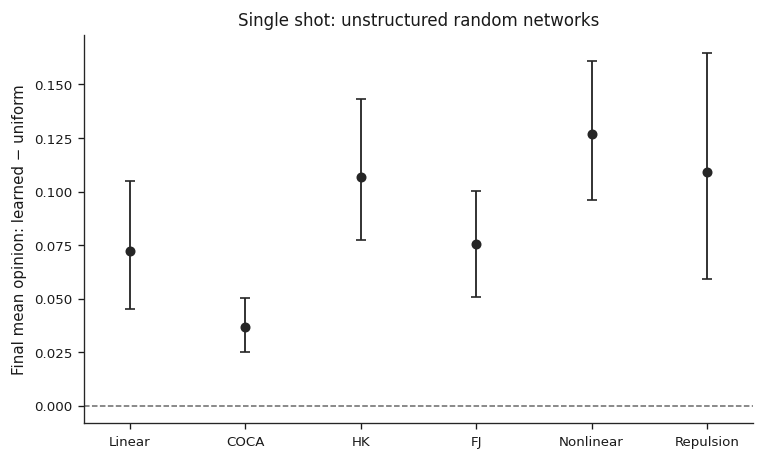

In [6]:
rows = unstructured_summary_df.copy()

means = rows["learned_minus_uniform_final_mean"].to_numpy(dtype=float)
lows = rows["learned_minus_uniform_final_ci_low"].to_numpy(dtype=float)
highs = rows["learned_minus_uniform_final_ci_high"].to_numpy(dtype=float)
cis = np.vstack([means - lows, highs - means])
labels = [DYNAMICS_LABELS[d] for d in rows["dynamics"]]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(rows))

ax.errorbar(
    x,
    means,
    yerr=cis,
    fmt="o",
    markersize=5,
    linewidth=1.1,
    capsize=3,
    color=("0.15" if PLOT_STYLE == "paper_bw" else POLICY_STYLE["learned"]["color"]),
)
ax.axhline(0.0, color="0.4", linewidth=0.9, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Single shot: unstructured random networks")
ax.margins(x=0.08)

save_figure(fig, "01_unstructured_all_dynamics_learned_minus_uniform")
plt.show()
plt.close(fig)


## Plot 2 — final policy performance on the matched unstructured benchmark


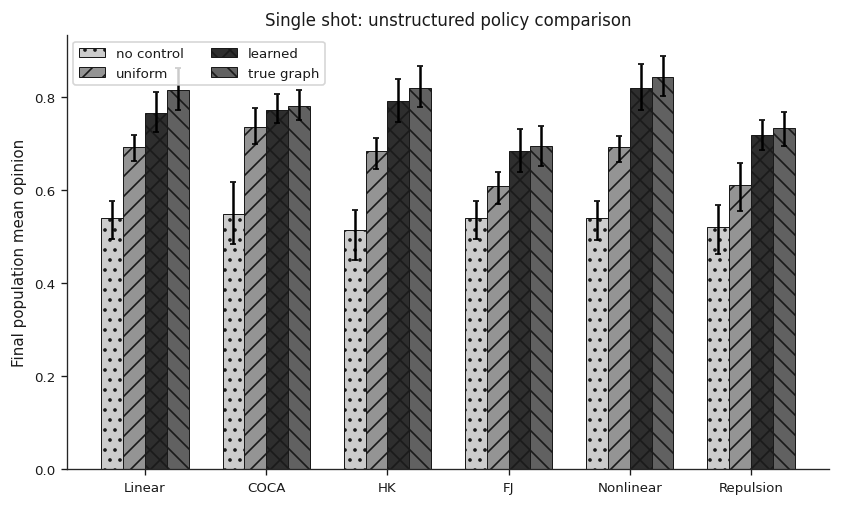

In [7]:
unstructured_env = env_level_df[
    env_level_df["scenario_class"] == "unstructured_random"
].copy()

policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "true_graph_final_mean",
}

fig, ax = plt.subplots(figsize=(8.2, 4.7))
x = np.arange(len(DYNAMICS_ORDER))
width = 0.18

for p_index, (policy, column) in enumerate(policy_columns.items()):
    means, lows, highs = [], [], []

    for dynamics in DYNAMICS_ORDER:
        group = unstructured_env[unstructured_env["dynamics"] == dynamics]
        mean, low, high = crossed_bootstrap_ci(
            group, column, seed=20260817 + p_index
        )
        means.append(mean); lows.append(low); highs.append(high)

    means = np.asarray(means)
    lows = np.asarray(lows)
    highs = np.asarray(highs)
    yerr = np.vstack([means - lows, highs - means])

    style = POLICY_STYLE[policy]
    ax.bar(
        x + (p_index - 1.5) * width,
        means,
        width=width,
        yerr=yerr,
        capsize=2,
        label=policy,
        color=style["color"],
        edgecolor="0.1",
        linewidth=0.6,
        hatch=style["hatch"],
    )

ax.set_xticks(x)
ax.set_xticklabels([DYNAMICS_LABELS[d] for d in DYNAMICS_ORDER])
ax.set_ylabel("Final population mean opinion")
ax.set_title("Single shot: unstructured policy comparison")
ax.legend(ncol=2)

save_figure(fig, "02_unstructured_final_policy_comparison")
plt.show()
plt.close(fig)


## Plot 3 — structured-mechanism policy comparison

The structured benchmark is shown in absolute policy space first. All four policies are retained so that the gain over uniform allocation can be interpreted relative to no control and to the true-graph reference.


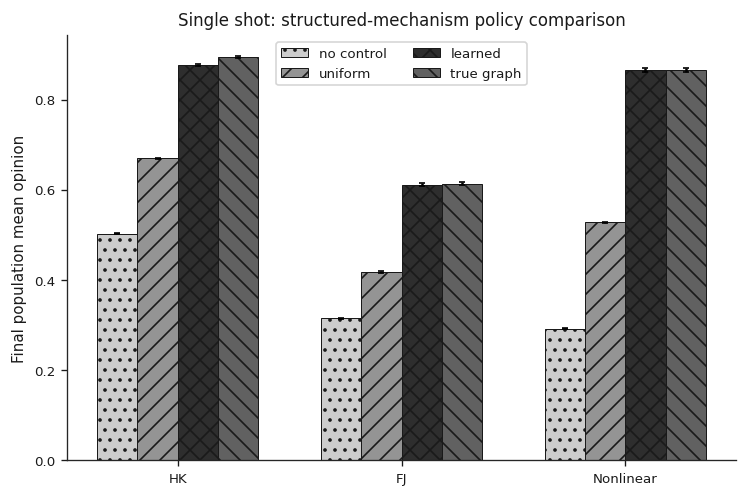

In [8]:
STRUCTURED_ORDER = [
    "hegselmannkrause",
    "friedkinjohnsen",
    "nonlinearinfluence",
]
structured_env = env_level_df[
    env_level_df["scenario_class"] == "structured_mechanism"
].copy()

policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "true_graph_final_mean",
}

fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(STRUCTURED_ORDER))
width = 0.18

for p_index, (policy, column) in enumerate(policy_columns.items()):
    means, lows, highs = [], [], []
    for dynamics in STRUCTURED_ORDER:
        group = structured_env[structured_env["dynamics"] == dynamics]
        mean, low, high = student_t_mean_ci(group[column].to_numpy(dtype=float))
        means.append(mean); lows.append(low); highs.append(high)

    means = np.asarray(means)
    lows = np.asarray(lows)
    highs = np.asarray(highs)
    yerr = np.vstack([means - lows, highs - means])
    style = POLICY_STYLE[policy]

    ax.bar(
        x + (p_index - 1.5) * width,
        means,
        width=width,
        yerr=yerr,
        capsize=2,
        label=policy,
        color=style["color"],
        edgecolor="0.1",
        linewidth=0.6,
        hatch=style["hatch"],
    )

ax.set_xticks(x)
ax.set_xticklabels([DYNAMICS_LABELS[d] for d in STRUCTURED_ORDER])
ax.set_ylabel("Final population mean opinion")
ax.set_title("Single shot: structured-mechanism policy comparison")
ax.legend(ncol=2)

save_figure(fig, "03_structured_final_policy_comparison")
plt.show()
plt.close(fig)


## Plot 4 — complete structured-family policy picture

Each panel resolves one dynamics into its three structured mechanism families while keeping all four policies. This is deliberately information-dense and is a strong candidate for the paper because it combines absolute performance, baseline context, and robustness across the nine structured families.


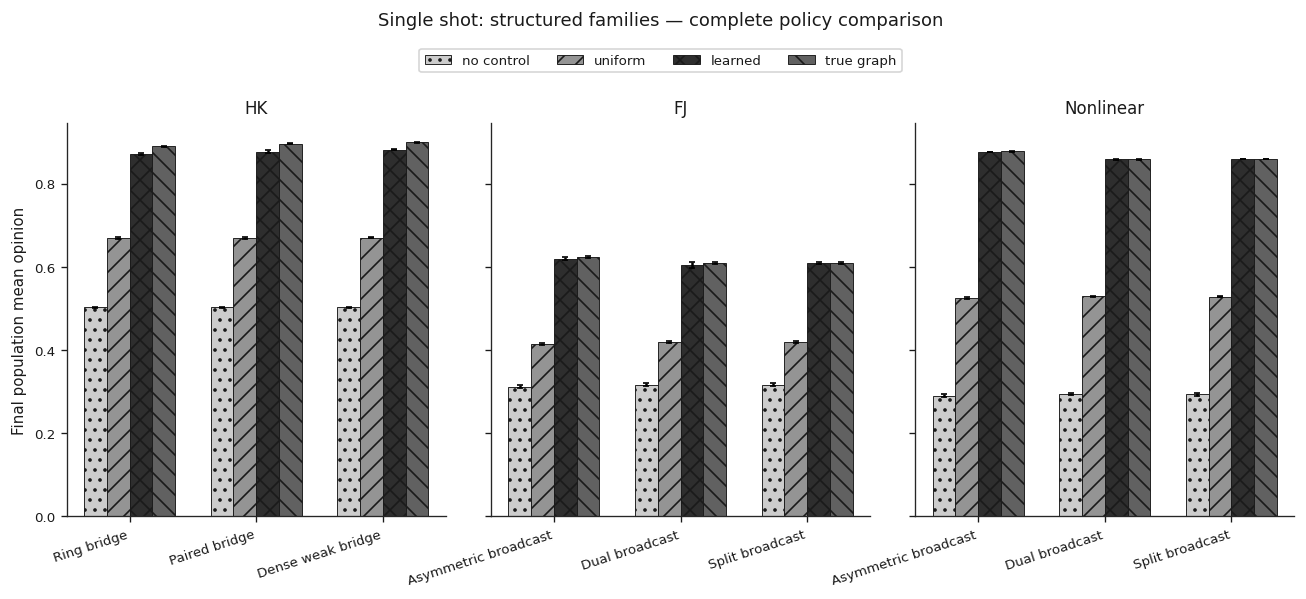

In [9]:
structured_env = env_level_df[
    env_level_df["scenario_class"] == "structured_mechanism"
].copy()

family_order = {
    "hegselmannkrause": ["ring_bridge", "paired_bridge", "dense_weak_bridge"],
    "friedkinjohnsen": ["asymmetric_broadcast", "dual_broadcast", "split_broadcast"],
    "nonlinearinfluence": ["asymmetric_broadcast", "dual_broadcast", "split_broadcast"],
}
policy_columns = {
    "no control": "no_control_final_mean",
    "uniform": "uniform_final_mean",
    "learned": "learned_final_mean",
    "true graph": "true_graph_final_mean",
}

fig, axes = plt.subplots(
    1, 3, figsize=(13.2, 4.25), sharey=True,
    gridspec_kw={"wspace": 0.12},
)
width = 0.18

for ax, dynamics in zip(axes, STRUCTURED_ORDER):
    families = family_order[dynamics]
    x = np.arange(len(families))

    for p_index, (policy, column) in enumerate(policy_columns.items()):
        means, lows, highs = [], [], []
        for family in families:
            group = structured_env[
                (structured_env["dynamics"] == dynamics)
                & (structured_env["family"] == family)
            ]
            mean, low, high = student_t_mean_ci(group[column].to_numpy(dtype=float))
            means.append(mean); lows.append(low); highs.append(high)

        means = np.asarray(means)
        lows = np.asarray(lows)
        highs = np.asarray(highs)
        yerr = np.vstack([means - lows, highs - means])
        style = POLICY_STYLE[policy]

        ax.bar(
            x + (p_index - 1.5) * width,
            means,
            width=width,
            yerr=yerr,
            capsize=2,
            label=policy,
            color=style["color"],
            edgecolor="0.1",
            linewidth=0.55,
            hatch=style["hatch"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [FAMILY_LABELS.get(f, f) for f in families],
        rotation=18,
        ha="right",
    )
    ax.set_title(DYNAMICS_LABELS[dynamics])

axes[0].set_ylabel("Final population mean opinion")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Single shot: structured families — complete policy comparison", y=1.10)

save_figure(fig, "04_structured_family_policy_comparison")
plt.show()
plt.close(fig)


## Paper candidate — complete benchmark policy overview

This two-panel figure is designed for limited article space. It combines the six matched generic dynamics and the three structured-mechanism dynamics while retaining all four policies.


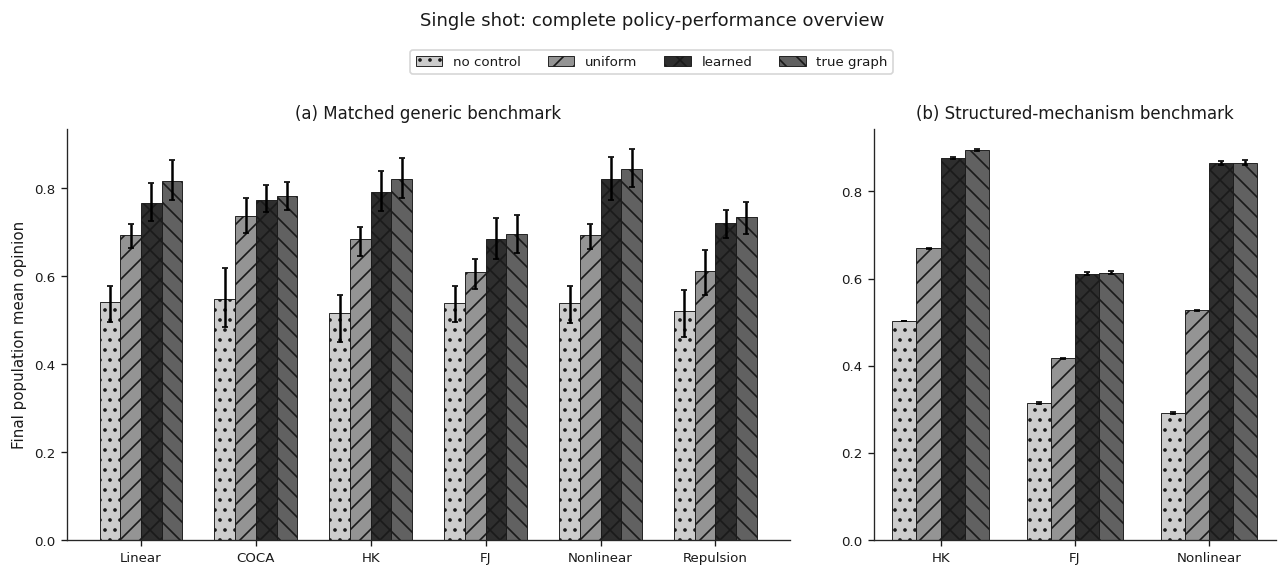

In [10]:
def draw_policy_bars(
    ax: plt.Axes,
    data: pd.DataFrame,
    dynamics_order: list[str],
    *,
    generic_crossed: bool,
    title: str,
) -> None:
    policy_columns = {
        "no control": "no_control_final_mean",
        "uniform": "uniform_final_mean",
        "learned": "learned_final_mean",
        "true graph": "true_graph_final_mean",
    }
    x = np.arange(len(dynamics_order))
    width = 0.18

    for p_index, (policy, column) in enumerate(policy_columns.items()):
        means, lows, highs = [], [], []
        for dynamics in dynamics_order:
            group = data[data["dynamics"] == dynamics]
            if generic_crossed:
                mean, low, high = crossed_bootstrap_ci(
                    group, column, seed=20260817 + p_index
                )
            else:
                mean, low, high = student_t_mean_ci(
                    group[column].to_numpy(dtype=float)
                )
            means.append(mean); lows.append(low); highs.append(high)

        means = np.asarray(means)
        lows = np.asarray(lows)
        highs = np.asarray(highs)
        yerr = np.vstack([means - lows, highs - means])
        style = POLICY_STYLE[policy]

        ax.bar(
            x + (p_index - 1.5) * width,
            means,
            width=width,
            yerr=yerr,
            capsize=1.8,
            label=policy,
            color=style["color"],
            edgecolor="0.1",
            linewidth=0.55,
            hatch=style["hatch"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels([DYNAMICS_LABELS[d] for d in dynamics_order])
    ax.set_title(title)


fig, axes = plt.subplots(
    1, 2, figsize=(13.0, 4.45),
    gridspec_kw={"width_ratios": [1.8, 1.0], "wspace": 0.15},
)

draw_policy_bars(
    axes[0],
    env_level_df[env_level_df["scenario_class"] == "unstructured_random"],
    DYNAMICS_ORDER,
    generic_crossed=True,
    title="(a) Matched generic benchmark",
)
draw_policy_bars(
    axes[1],
    env_level_df[env_level_df["scenario_class"] == "structured_mechanism"],
    STRUCTURED_ORDER,
    generic_crossed=False,
    title="(b) Structured-mechanism benchmark",
)

axes[0].set_ylabel("Final population mean opinion")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Single shot: complete policy-performance overview", y=1.10)

save_figure(fig, "04b_complete_policy_overview")
plt.show()
plt.close(fig)


## Plot 5 — paired effect-size overview

Absolute policy bars are the primary presentation. This compact companion figure shows the two most interpretable paired contrasts directly: learned minus uniform and learned minus the true-graph reference. It replaces the unstable ``fraction of true-graph reference advantage recovered'' ratio.


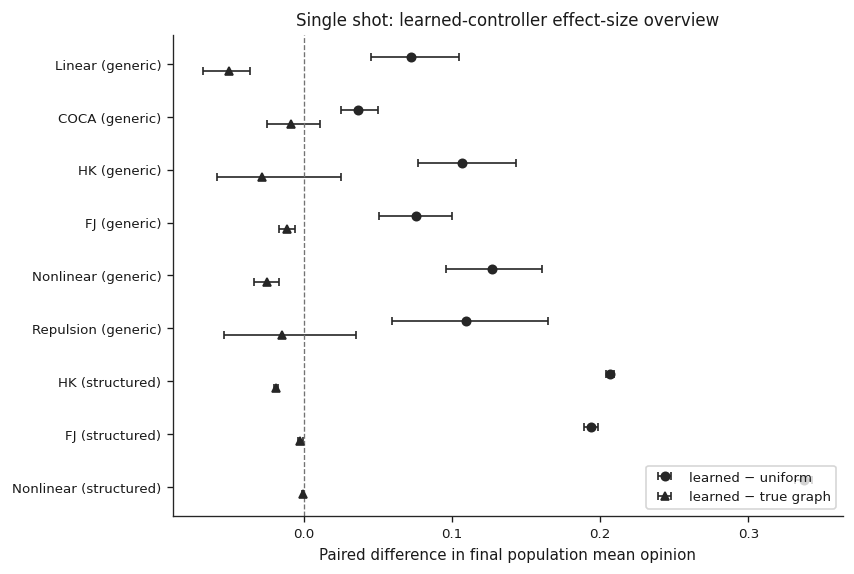

In [11]:
effect_rows = []
ordered_groups = [
    ("unstructured_random", d) for d in DYNAMICS_ORDER
] + [
    ("structured_mechanism", d) for d in STRUCTURED_ORDER
]

for scenario_class, dynamics in ordered_groups:
    group = env_level_df[
        (env_level_df["scenario_class"] == scenario_class)
        & (env_level_df["dynamics"] == dynamics)
    ]
    if group.empty:
        continue

    for contrast, column in [
        ("learned − uniform", "learned_gap_final"),
        ("learned − true graph", "learned_minus_true_graph_final"),
    ]:
        mean, low, high, method = mean_ci_for_group(group, column)
        effect_rows.append({
            "scenario_class": scenario_class,
            "dynamics": dynamics,
            "contrast": contrast,
            "mean": mean,
            "ci_low": low,
            "ci_high": high,
            "ci_method": method,
        })

effect_df = pd.DataFrame(effect_rows)
effect_df.to_csv(RESULTS_DIR / "paired_effect_size_overview.csv", index=False)

labels = []
for scenario_class, dynamics in ordered_groups:
    if not (
        (effect_df["scenario_class"] == scenario_class)
        & (effect_df["dynamics"] == dynamics)
    ).any():
        continue
    suffix = "generic" if scenario_class == "unstructured_random" else "structured"
    labels.append(f"{DYNAMICS_LABELS[dynamics]} ({suffix})")

fig, ax = plt.subplots(figsize=(7.2, 5.2))
y = np.arange(len(labels))
offset = 0.13

for contrast, marker, yoff in [
    ("learned − uniform", "o", -offset),
    ("learned − true graph", "^", offset),
]:
    sub = effect_df[effect_df["contrast"] == contrast].copy()
    means = sub["mean"].to_numpy(dtype=float)
    lows = sub["ci_low"].to_numpy(dtype=float)
    highs = sub["ci_high"].to_numpy(dtype=float)
    xerr = np.vstack([means - lows, highs - means])

    ax.errorbar(
        means,
        y + yoff,
        xerr=xerr,
        fmt=marker,
        capsize=2.5,
        linewidth=1.0,
        markersize=5,
        label=contrast,
        color=("0.15" if PLOT_STYLE == "paper_bw" else None),
    )

ax.axvline(0.0, color="0.45", linestyle="--", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Paired difference in final population mean opinion")
ax.set_title("Single shot: learned-controller effect-size overview")
ax.legend(loc="lower right")

save_figure(fig, "05_paired_effect_size_overview")
plt.show()
plt.close(fig)


## Plot 6 — prediction fit versus control improvement


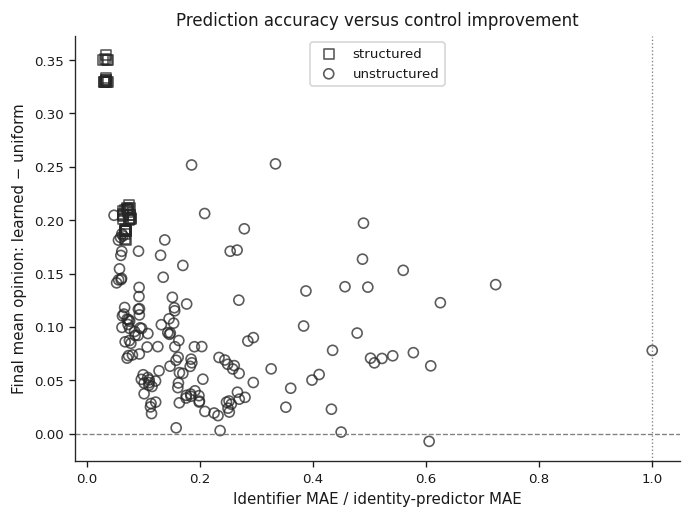

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.6))

marker_by_scenario = {
    "unstructured_random": "o",
    "structured_mechanism": "s",
}

for scenario_class, group in env_level_df.groupby(
    "scenario_class"
):
    marker = marker_by_scenario[scenario_class]

    ax.scatter(
        group["final_fit_model_over_identity"],
        group["learned_gap_final"],
        marker=marker,
        alpha=0.75,
        label=(
            "unstructured"
            if scenario_class == "unstructured_random"
            else "structured"
        ),
        facecolors=(
            "none"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
        edgecolors=(
            "0.15"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
    )

ax.axhline(
    0.0,
    color="0.5",
    linewidth=0.8,
    linestyle="--",
)
ax.axvline(
    1.0,
    color="0.5",
    linewidth=0.8,
    linestyle=":",
)
ax.set_xlabel("Identifier MAE / identity-predictor MAE")
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Prediction accuracy versus control improvement")
ax.legend()

save_figure(
    fig,
    "06_fit_vs_control_gain",
)
plt.show()
plt.close(fig)

## Cached rollout loader for trajectory plots


In [13]:
def _load_policy_from_npz(
    arrays: Any,
    policy: str,
) -> dict[str, Any]:
    inter_keys = sorted(
        key
        for key in arrays.files
        if key.startswith(
            f"{policy}__intermediate__"
        )
    )

    return {
        "policy": policy,
        "states": arrays[f"{policy}__states"],
        "actions": arrays[f"{policy}__actions"],
        "intermediate_states_list": [
            arrays[key]
            for key in inter_keys
        ],
    }


def load_baseline_rollout(
    environment_id: str,
    policy: str,
) -> dict[str, Any]:
    cache_dir = Path(
        ENV_INDEX[environment_id]["cache_dir"]
    )
    arrays = np.load(
        cache_dir / "baselines.npz",
        allow_pickle=False,
    )
    return _load_policy_from_npz(arrays, policy)


def load_learned_rollout(
    environment_id: str,
    learning_seed: int,
) -> dict[str, Any]:
    cache_dir = Path(
        ENV_INDEX[environment_id]["cache_dir"]
    )
    learned_root = cache_dir / "learned"

    matches = list(
        learned_root.glob(
            f"seed_{int(learning_seed):02d}_*/rollout.npz"
        )
    )
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one learned rollout for "
            f"{environment_id}, seed={learning_seed}; "
            f"found {len(matches)}"
        )

    arrays = np.load(
        matches[0],
        allow_pickle=False,
    )
    return _load_policy_from_npz(
        arrays,
        "learned_nonlinear",
    )


T_CAMPAIGN = float(
    RUN_MANIFEST["scientific_config"]["t_campaign"]
)
T_S = float(
    RUN_MANIFEST["scientific_config"]["t_s"]
)
TARGET = float(
    RUN_MANIFEST["scientific_config"]["target"]
)


def fine_trajectory(
    rollout: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray]:
    times = [0.0]
    states = [
        np.asarray(rollout["states"][0], dtype=float)
    ]

    for campaign, inter in enumerate(
        rollout["intermediate_states_list"]
    ):
        inter = np.asarray(inter, dtype=float)
        t0 = campaign * T_CAMPAIGN

        times.append(t0)
        states.append(inter[0])

        for step in range(1, len(inter)):
            times.append(t0 + step * T_S)
            states.append(inter[step])

    return (
        np.asarray(times, dtype=float),
        np.asarray(states, dtype=float),
    )


def representative_learning_seed(
    environment_id: str,
) -> int:
    rows = (
        learned_df[
            learned_df["environment_id"] == environment_id
        ]
        .sort_values("final_mean")
        .reset_index(drop=True)
    )

    median_value = float(rows["final_mean"].median())

    index = (
        rows["final_mean"] - median_value
    ).abs().idxmin()

    return int(rows.loc[index, "learning_seed"])

In [14]:
def load_environment_definition(
    environment_id: str,
) -> dict[str, Any]:
    cache_dir = Path(
        ENV_INDEX[environment_id]["cache_dir"]
    )

    npz_path = cache_dir / "environment_definition.npz"
    json_path = cache_dir / "environment_definition.json"

    if not npz_path.exists() or not json_path.exists():
        raise FileNotFoundError(
            "Environment definition is missing from the cache. "
            "Run experiment_2026_08_17_broad_all_dynamics_"
            "multitopology_multiseed_BACKFILL.ipynb normally once. "
            "It only writes missing graph/opinion definitions and "
            "does NOT rerun learned models or rollouts."
        )

    arrays = np.load(
        npz_path,
        allow_pickle=False,
    )
    metadata = json.loads(
        json_path.read_text(encoding="utf-8")
    )

    result = dict(metadata)
    result["A"] = np.asarray(arrays["A"], dtype=float)
    result["x0"] = np.asarray(arrays["x0"], dtype=float)
    result["v_true"] = np.asarray(
        arrays["v_true"],
        dtype=float,
    )

    if "raw" in arrays.files:
        result["raw"] = np.asarray(
            arrays["raw"],
            dtype=float,
        )

    return result

## Predetermined representative environments

These are fixed by seed/family, not selected after inspecting the learned
outcome.

For every dynamics we show one original unstructured environment:
topology seed 3, opinion seed 0.

For the three structured models we also show the canonical structured family
used in the preceding experiment.


In [15]:
CANONICAL_UNSTRUCTURED = {
    dynamics: (
        f"unstructured__{dynamics}__topo03__x00"
    )
    for dynamics in DYNAMICS_ORDER
}

CANONICAL_STRUCTURED = {
    "hegselmannkrause": (
        "structured__hegselmannkrause"
        "__ring_bridge__env00"
    ),
    "friedkinjohnsen": (
        "structured__friedkinjohnsen"
        "__asymmetric_broadcast__env00"
    ),
    "nonlinearinfluence": (
        "structured__nonlinearinfluence"
        "__asymmetric_broadcast__env00"
    ),
}

display(
    pd.DataFrame(
        [
            {
                "dynamics": dynamics,
                "unstructured_environment": environment_id,
                "representative_learning_seed": (
                    representative_learning_seed(
                        environment_id
                    )
                ),
            }
            for dynamics, environment_id
            in CANONICAL_UNSTRUCTURED.items()
        ]
    )
)

,dynamics,unstructured_environment,representative_learning_seed
0,laplacian,unstructured__laplacian__topo03__x00,0
1,coca,unstructured__coca__topo03__x00,2
2,hegselmannkrause,unstructured__hegselmannkrause__topo03__x00,2
3,friedkinjohnsen,unstructured__friedkinjohnsen__topo03__x00,2
4,nonlinearinfluence,unstructured__nonlinearinfluence__topo03__x00,0
5,repulsion,unstructured__repulsion__topo03__x00,2


## Plot 7 — representative mean trajectories for all six dynamics


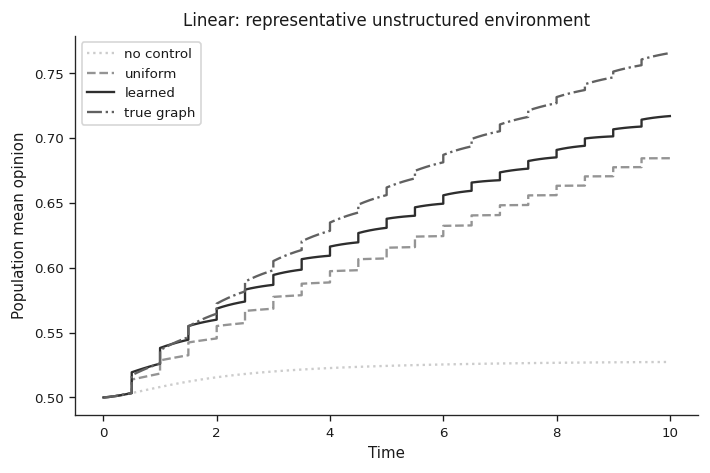

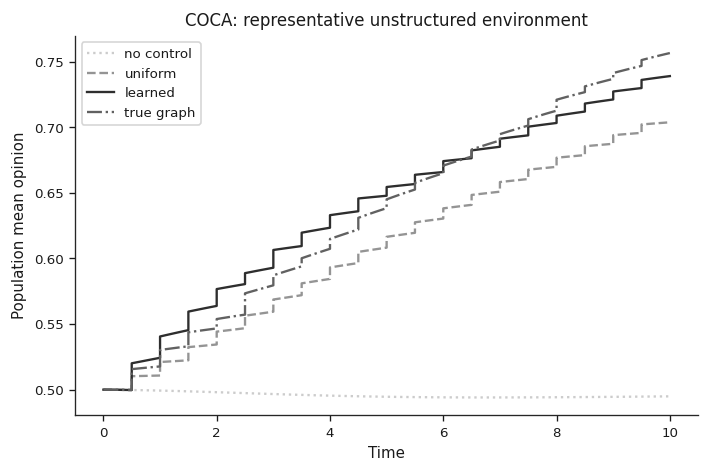

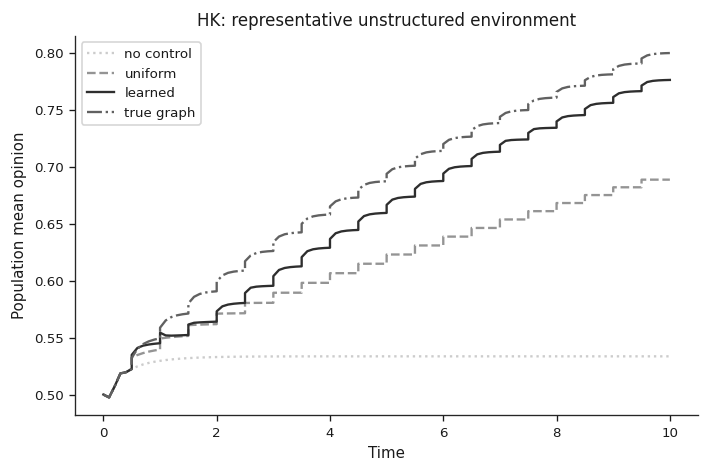

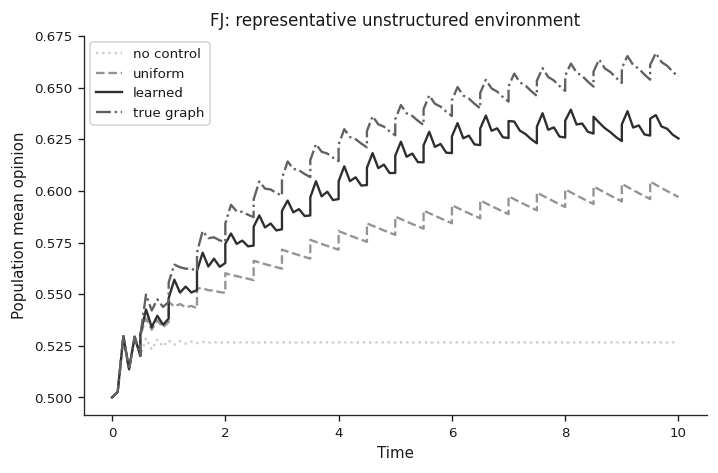

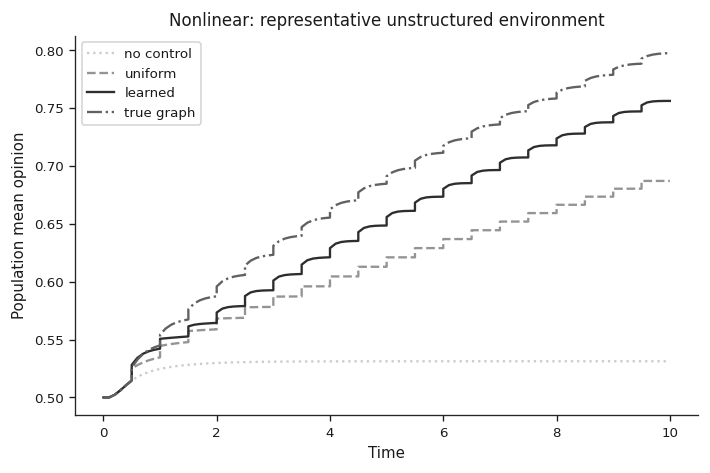

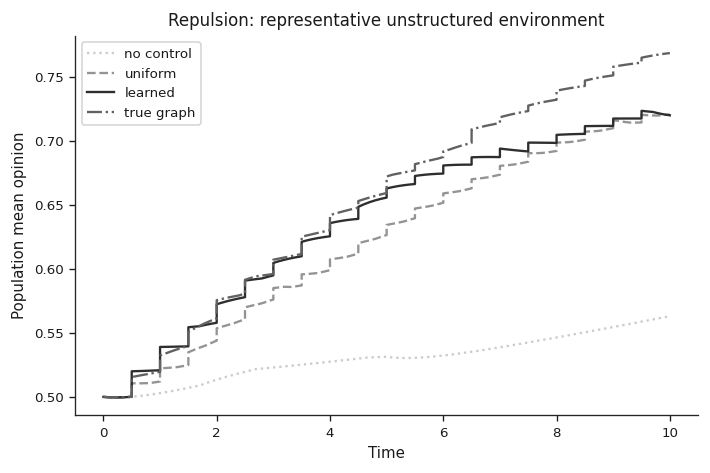

In [16]:
for dynamics in DYNAMICS_ORDER:
    environment_id = CANONICAL_UNSTRUCTURED[dynamics]
    rep_seed = representative_learning_seed(environment_id)

    rollouts = {
        "no control": load_baseline_rollout(
            environment_id,
            "no_control",
        ),
        "uniform": load_baseline_rollout(
            environment_id,
            "uniform",
        ),
        "learned": load_learned_rollout(
            environment_id,
            rep_seed,
        ),
        "true graph": load_baseline_rollout(
            environment_id,
            "true_graph",
        ),
    }

    fig, ax = plt.subplots(figsize=(6.7, 4.1))

    for policy, rollout in rollouts.items():
        times, states = fine_trajectory(rollout)
        style = POLICY_STYLE[policy]

        ax.plot(
            times,
            states.mean(axis=1),
            label=policy,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=None,
            linewidth=1.4,
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Population mean opinion")
    ax.set_title(
        f"{DYNAMICS_LABELS[dynamics]}: "
        "representative unstructured environment"
    )
    ax.legend()

    save_figure(
        fig,
        f"07_unstructured_mean_trajectory_{dynamics}",
    )
    plt.show()
    plt.close(fig)

## Plot 8 — individual-node trajectories for the canonical structured cases


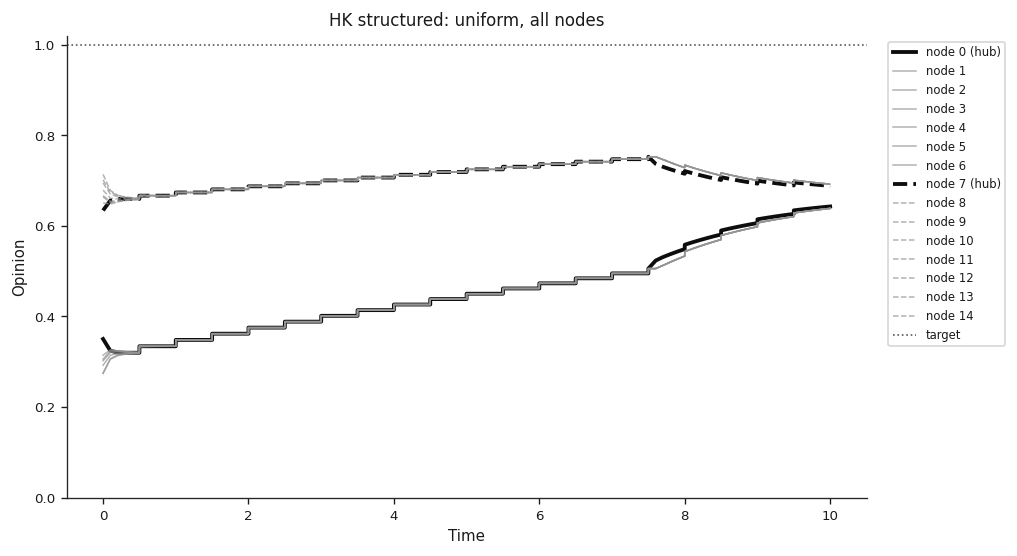

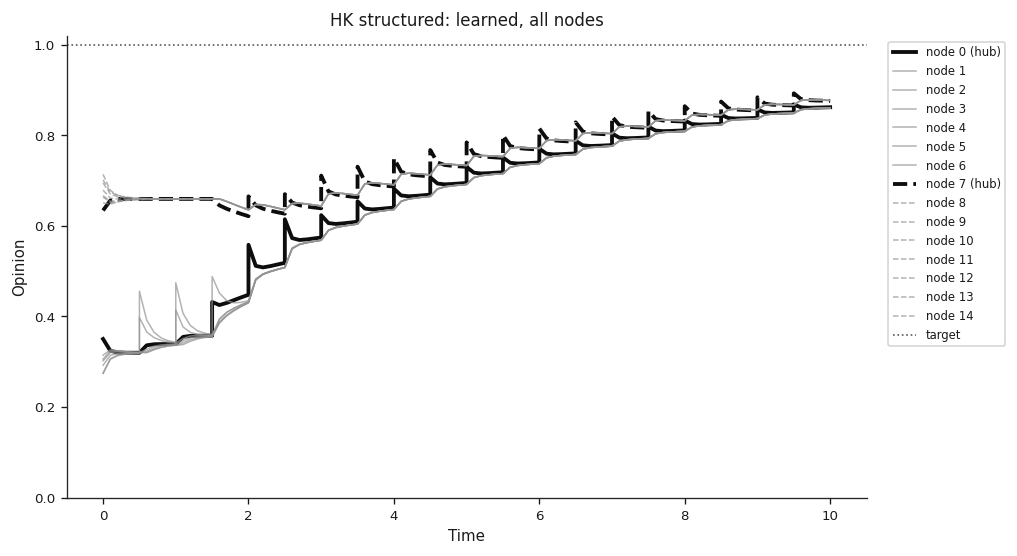

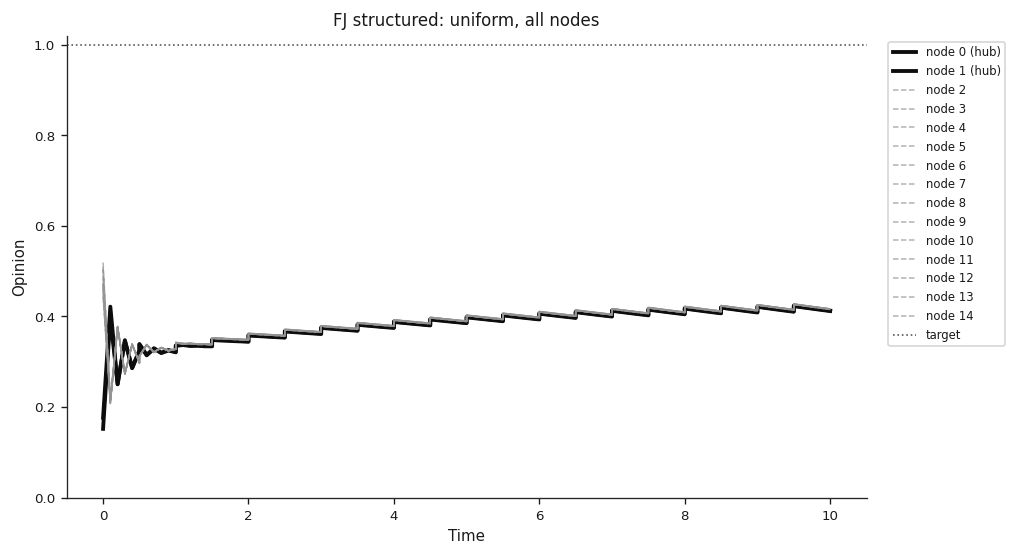

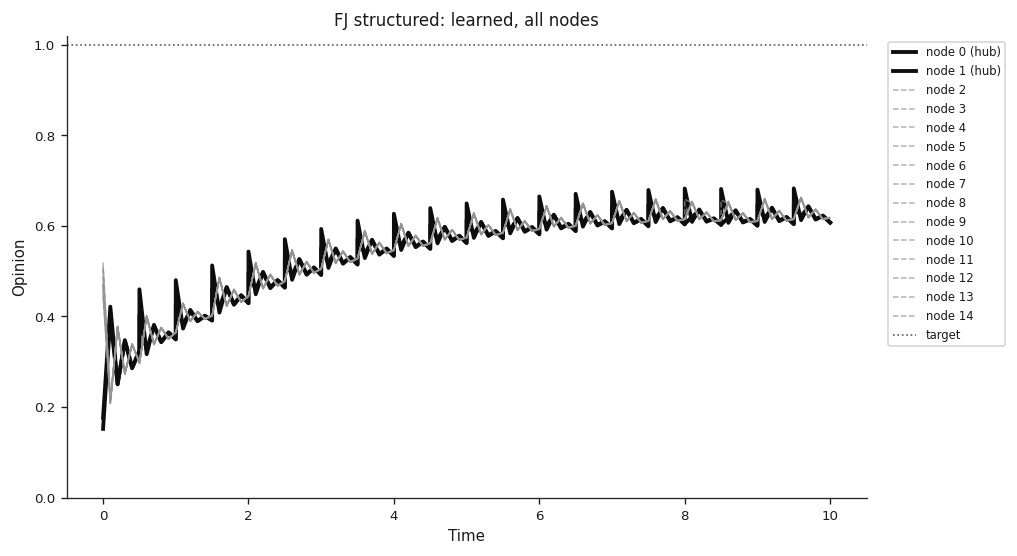

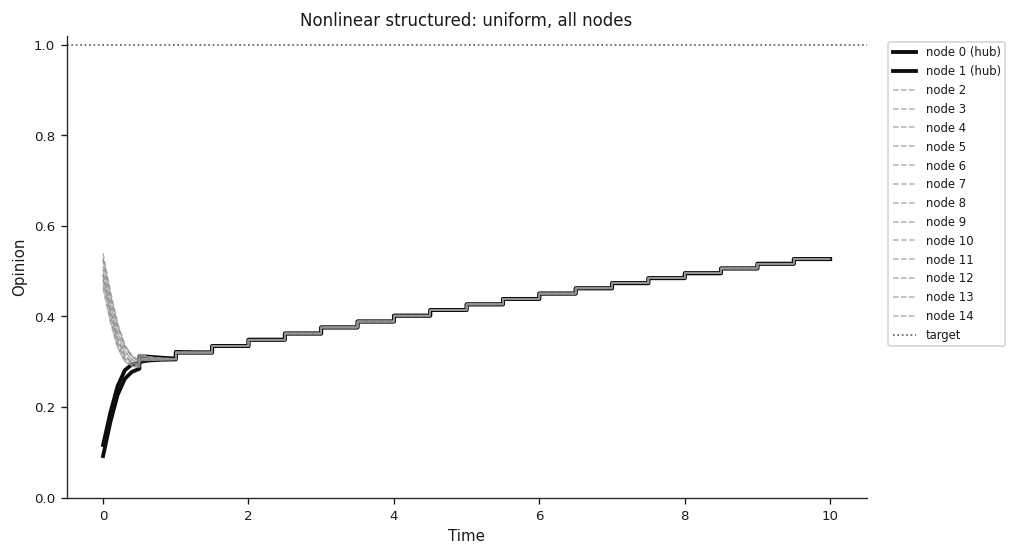

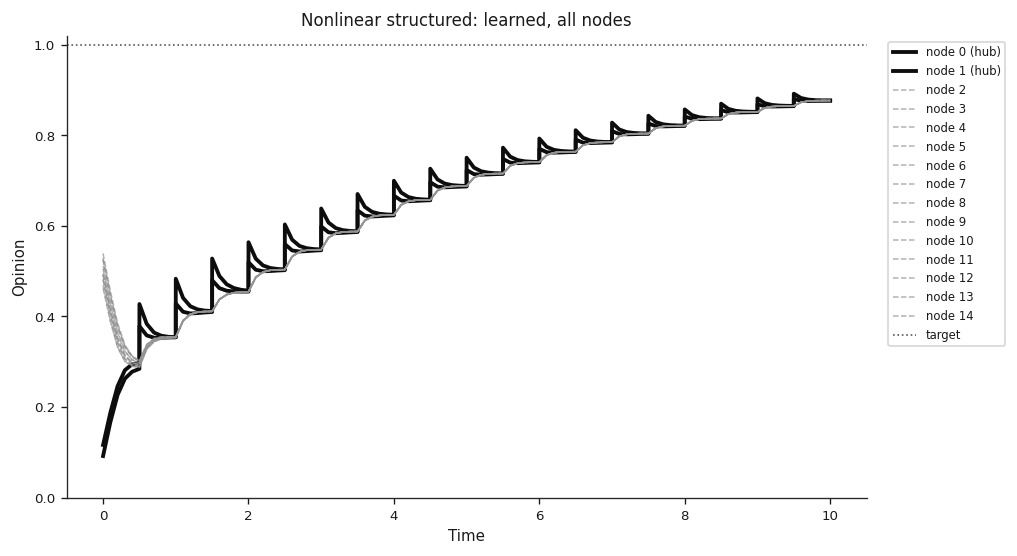

In [17]:
def plot_all_nodes(
    rollout: dict[str, Any],
    *,
    dynamics: str,
    title: str,
    stem: str,
) -> None:
    times, states = fine_trajectory(rollout)

    fig, ax = plt.subplots(figsize=(8.6, 5.0))

    if dynamics == "hegselmannkrause":
        hubs = {0, 7}
        low_cluster = set(range(0, 7))
    else:
        hubs = {0, 1}
        low_cluster = set()

    for node in range(states.shape[1]):
        is_hub = node in hubs

        if dynamics == "hegselmannkrause":
            linestyle = "-" if node in low_cluster else "--"
        else:
            linestyle = "-" if is_hub else "--"

        if PLOT_STYLE == "paper_bw":
            color = "0.05" if is_hub else "0.58"
        else:
            color = None

        ax.plot(
            times,
            states[:, node],
            linewidth=2.3 if is_hub else 0.9,
            linestyle=linestyle,
            color=color,
            alpha=1.0 if is_hub else 0.72,
            label=(
                f"node {node}"
                + (" (hub)" if is_hub else "")
            ),
        )

    ax.axhline(
        TARGET,
        color="0.35",
        linestyle=":",
        linewidth=1.0,
        label="target",
    )
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel("Time")
    ax.set_ylabel("Opinion")
    ax.set_title(title)
    ax.legend(
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        fontsize=7,
    )

    save_figure(fig, stem)
    plt.show()
    plt.close(fig)


for dynamics, environment_id in CANONICAL_STRUCTURED.items():
    rep_seed = representative_learning_seed(environment_id)

    learned_rollout = load_learned_rollout(
        environment_id,
        rep_seed,
    )
    uniform_rollout = load_baseline_rollout(
        environment_id,
        "uniform",
    )

    plot_all_nodes(
        uniform_rollout,
        dynamics=dynamics,
        title=(
            f"{DYNAMICS_LABELS[dynamics]} structured: "
            "uniform, all nodes"
        ),
        stem=(
            f"08_structured_all_nodes_uniform_{dynamics}"
        ),
    )

    plot_all_nodes(
        learned_rollout,
        dynamics=dynamics,
        title=(
            f"{DYNAMICS_LABELS[dynamics]} structured: "
            "learned, all nodes"
        ),
        stem=(
            f"08_structured_all_nodes_learned_{dynamics}"
        ),
    )

## Plot 9 — learned action heatmaps for the structured cases


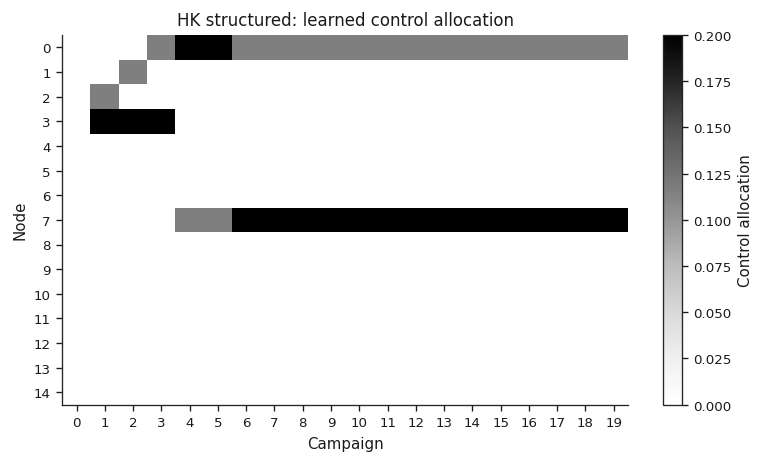

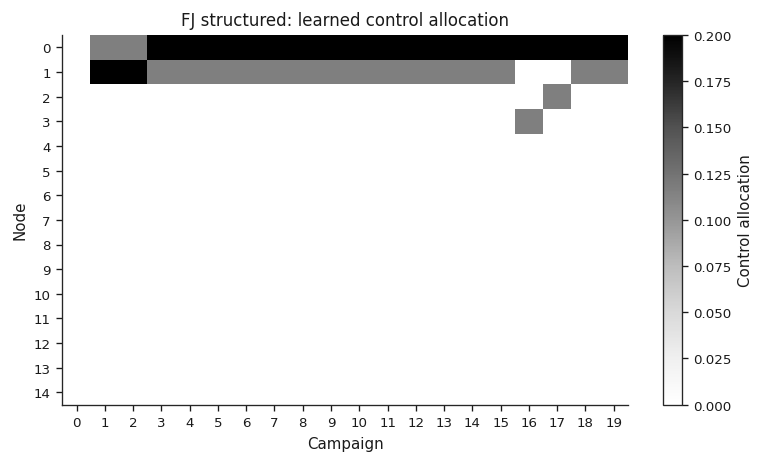

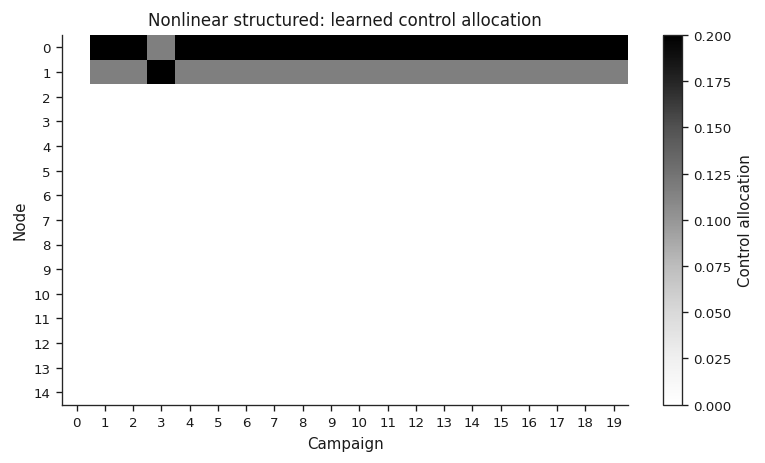

In [18]:
for dynamics, environment_id in CANONICAL_STRUCTURED.items():
    rep_seed = representative_learning_seed(environment_id)
    rollout = load_learned_rollout(
        environment_id,
        rep_seed,
    )

    actions = np.asarray(
        rollout["actions"],
        dtype=float,
    )

    fig, ax = plt.subplots(figsize=(7.6, 4.0))

    cmap = "Greys" if PLOT_STYLE == "paper_bw" else "viridis"

    image = ax.imshow(
        actions.T,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
    )
    ax.set_xlabel("Campaign")
    ax.set_ylabel("Node")
    ax.set_xticks(np.arange(actions.shape[0]))
    ax.set_yticks(np.arange(actions.shape[1]))
    ax.set_title(
        f"{DYNAMICS_LABELS[dynamics]} structured: "
        "learned control allocation"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Control allocation",
    )

    save_figure(
        fig,
        f"09_structured_learned_actions_{dynamics}",
    )
    plt.show()
    plt.close(fig)

## Benchmark-family definitions

The broad experiment contains two conceptually different kinds of environments.

### Original unstructured benchmark — `barabasi_albert_spread`

This is the **generic benchmark used before the mechanism-specific topology studies**.

For every propagation law:

- the network has 15 nodes;
- connectivity is generated from a Barabási--Albert graph with `m = 2`;
- the same five graph seeds (`3, 4, 5, 6, 7`) are reused across all six dynamics;
- the initial opinions are the 15 equally spaced values from 0 to 1,
  randomly permuted using five opinion seeds (`0, 1, 2, 4, 5`);
- therefore every dynamics model is evaluated on the same 25 graph/opinion
  combinations.

The graph is **not designed around a particular control mechanism**.
Central nodes arise naturally from preferential attachment, while opinions are deliberately spread across the full opinion interval.
This makes `barabasi_albert_spread` the main apples-to-apples benchmark for comparing all six propagation laws.

The graph generator also uses the repository's existing Barabási--Albert
pruning/validity settings (`ba_prune_max_frac = 0.5`, `ba_qsc_tol = 1e-8`,
`ba_max_tries = 500`). Those are implementation settings of the generic graph
generator rather than additional topology families.

### Structured mechanism benchmarks

The remaining families are **deliberately structured stress tests**.
They are not intended to replace the original random benchmark.
Instead, they create network configurations in which graph-aware intervention
has a specific mechanism to exploit:

- HK: activating a confidence-limited inter-cluster bridge;
- FJ: targeting influential broadcasters rather than spreading budget over followers;
- nonlinear influence: targeting influential broadcasters whose state-dependent
  interaction can otherwise oppose the control objective.


In [19]:
benchmark_family_glossary_df = pd.DataFrame(
    [
        {
            "scenario_class": "unstructured_random",
            "family": "barabasi_albert_spread",
            "dynamics": "all six dynamics",
            "graph_definition": (
                "15-node Barabasi-Albert graph, m=2, "
                "five matched topology seeds"
            ),
            "initial_opinions": (
                "15 equally spaced values on [0,1], "
                "permuted with five matched opinion seeds"
            ),
            "scientific_role": (
                "generic apples-to-apples benchmark; "
                "not designed around a specific control mechanism"
            ),
        },
        {
            "scenario_class": "structured_mechanism",
            "family": "HK bridge families",
            "dynamics": "HK",
            "graph_definition": (
                "two internally connected communities whose only "
                "cross-community topological edge is between the hubs"
            ),
            "initial_opinions": (
                "two compact opinion clusters separated beyond HK confidence"
            ),
            "scientific_role": (
                "tests whether learned targeting activates a latent bridge "
                "earlier than uniform intervention"
            ),
        },
        {
            "scenario_class": "structured_mechanism",
            "family": "broadcast families",
            "dynamics": "FJ / nonlinear influence",
            "graph_definition": (
                "two highly influential broadcaster hubs plus peripheral leaves"
            ),
            "initial_opinions": (
                "broadcaster hubs start lower than the leaf population"
            ),
            "scientific_role": (
                "tests whether learned targeting acts on influential sources "
                "rather than distributing budget across followers"
            ),
        },
    ]
)

benchmark_family_glossary_df.to_csv(
    RESULTS_DIR / "benchmark_family_glossary.csv",
    index=False,
)

display(benchmark_family_glossary_df)

,scenario_class,family,dynamics,graph_definition,initial_opinions,scientific_role
0,unstructured_random,barabasi_albert_spread,all six dynamics,"15-node Barabasi-Albert graph, m=2, five match...","15 equally spaced values on [0,1], permuted wi...",generic apples-to-apples benchmark; not design...
1,structured_mechanism,HK bridge families,HK,two internally connected communities whose onl...,two compact opinion clusters separated beyond ...,tests whether learned targeting activates a la...
2,structured_mechanism,broadcast families,FJ / nonlinear influence,two highly influential broadcaster hubs plus p...,broadcaster hubs start lower than the leaf pop...,tests whether learned targeting acts on influe...


## Structured family glossary

The structured benchmark families were intentionally designed to create **specific control bottlenecks**.

### HK families
All three HK families contain **two internally coherent clusters** connected only through the two hub nodes.
Because HK interaction depends on a confidence threshold, control works mainly by pushing the two hubs close enough that the bridge becomes active and the two clusters can start influencing one another.

- **ring_bridge**  
  Each cluster is organized as a hub with leaves plus a light ring among the leaves.  
  This is the most orderly local communication pattern.

- **paired_bridge**  
  Each cluster again has a dominant hub, but leaf-to-leaf communication happens mostly in isolated pairs.  
  This gives weaker within-cluster mixing than the ring case.

- **dense_weak_bridge**  
  Each cluster has many leaf-to-leaf links, but they are individually weak.  
  Once the bridge is activated, information can diffuse broadly because the cluster is internally well connected.

### FJ / nonlinear-influence families
These families contain **two highly central broadcaster nodes** and a population of leaves.
The broadcasters sit at lower initial opinions, while the leaves start higher.
The control problem is to decide how strongly to target the broadcasters so that their influence propagates through the rest of the network.

- **asymmetric_broadcast**  
  Both hubs influence the leaf population, but one hub is clearly the dominant broadcaster and the other is secondary.  
  This creates a strong ranking asymmetry.

- **dual_broadcast**  
  The two hubs broadcast approximately symmetrically to the same leaf population.  
  A good policy should typically use both hubs in a balanced way.

- **split_broadcast**  
  The leaf population is split into two subgroups, each mostly influenced by one broadcaster, with a weaker cross-effect from the other.  
  This creates a structured two-region intervention problem.


In [20]:
family_glossary_rows = [
    {
        "dynamics": "hegselmannkrause",
        "family": "ring_bridge",
        "mechanism": "two clusters connected only by the two hubs",
        "topology_meaning": "leaf nodes form a light ring within each cluster",
        "control_meaning": "control must pull the two hubs into confidence range so the bridge activates",
    },
    {
        "dynamics": "hegselmannkrause",
        "family": "paired_bridge",
        "mechanism": "two clusters connected only by the two hubs",
        "topology_meaning": "leaf nodes communicate mainly in disjoint pairs",
        "control_meaning": "bridge activation still depends on the hubs, but within-cluster mixing is sparser",
    },
    {
        "dynamics": "hegselmannkrause",
        "family": "dense_weak_bridge",
        "mechanism": "two clusters connected only by the two hubs",
        "topology_meaning": "many weak leaf-to-leaf links within each cluster",
        "control_meaning": "after bridge activation, diffusion can spread through the dense cluster interior",
    },
    {
        "dynamics": "friedkinjohnsen",
        "family": "asymmetric_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "one hub is the dominant broadcaster and the other is secondary",
        "control_meaning": "a good policy should recognize the stronger hub and exploit the asymmetry",
    },
    {
        "dynamics": "friedkinjohnsen",
        "family": "dual_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "both hubs broadcast symmetrically to the leaves",
        "control_meaning": "the policy should usually split attention across both important hubs",
    },
    {
        "dynamics": "friedkinjohnsen",
        "family": "split_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "each hub mainly influences one subgroup of leaves, with weaker cross-effects",
        "control_meaning": "control must coordinate across two partially separated regions",
    },
    {
        "dynamics": "nonlinearinfluence",
        "family": "asymmetric_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "one hub is the dominant broadcaster and the other is secondary",
        "control_meaning": "state-dependent interaction strength amplifies the value of identifying the main broadcaster",
    },
    {
        "dynamics": "nonlinearinfluence",
        "family": "dual_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "both hubs broadcast symmetrically to the leaves",
        "control_meaning": "the policy should leverage both hubs while the nonlinear interaction law modulates propagation",
    },
    {
        "dynamics": "nonlinearinfluence",
        "family": "split_broadcast",
        "mechanism": "two low-opinion broadcasters influence a higher-opinion leaf population",
        "topology_meaning": "each hub mainly influences one subgroup of leaves, with weaker cross-effects",
        "control_meaning": "the policy must exploit both topology and state-dependent interactions across the two subgroups",
    },
]

family_glossary_df = pd.DataFrame(family_glossary_rows)
family_glossary_df["dynamics_label"] = family_glossary_df["dynamics"].map(DYNAMICS_LABELS)

family_glossary_df.to_csv(
    RESULTS_DIR / "structured_family_glossary.csv",
    index=False,
)

display(
    family_glossary_df[
        [
            "dynamics_label",
            "family",
            "mechanism",
            "topology_meaning",
            "control_meaning",
        ]
    ]
)

,dynamics_label,family,mechanism,topology_meaning,control_meaning
0,HK,ring_bridge,two clusters connected only by the two hubs,leaf nodes form a light ring within each cluster,control must pull the two hubs into confidence...
1,HK,paired_bridge,two clusters connected only by the two hubs,leaf nodes communicate mainly in disjoint pairs,"bridge activation still depends on the hubs, b..."
2,HK,dense_weak_bridge,two clusters connected only by the two hubs,many weak leaf-to-leaf links within each cluster,"after bridge activation, diffusion can spread ..."
3,FJ,asymmetric_broadcast,two low-opinion broadcasters influence a highe...,one hub is the dominant broadcaster and the ot...,a good policy should recognize the stronger hu...
4,FJ,dual_broadcast,two low-opinion broadcasters influence a highe...,both hubs broadcast symmetrically to the leaves,the policy should usually split attention acro...
5,FJ,split_broadcast,two low-opinion broadcasters influence a highe...,each hub mainly influences one subgroup of lea...,control must coordinate across two partially s...
6,Nonlinear,asymmetric_broadcast,two low-opinion broadcasters influence a highe...,one hub is the dominant broadcaster and the ot...,state-dependent interaction strength amplifies...
7,Nonlinear,dual_broadcast,two low-opinion broadcasters influence a highe...,both hubs broadcast symmetrically to the leaves,the policy should leverage both hubs while the...
8,Nonlinear,split_broadcast,two low-opinion broadcasters influence a highe...,each hub mainly influences one subgroup of lea...,the policy must exploit both topology and stat...


## Structured family-level head-to-head summary

This is the compact quantitative view of the table you shared.  
Each point is the **environment-level mean** of

\[
\text{learned final mean opinion} - \text{uniform final mean opinion}
\]

with a 95% confidence interval over the five distinct environments in that family.


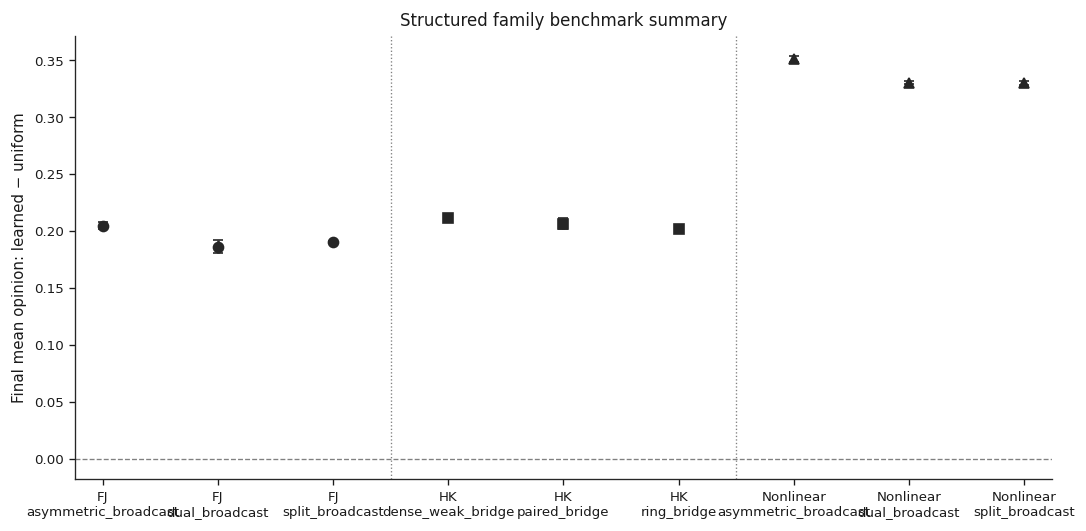

,dynamics,family,learned_minus_uniform_final_mean,final_ci95_half,environment_win_rate,learned_minus_true_graph_final_mean
0,friedkinjohnsen,asymmetric_broadcast,0.20506,0.00306,1.0,-0.00312
1,friedkinjohnsen,dual_broadcast,0.18653,0.00539,1.0,-0.00416
2,friedkinjohnsen,split_broadcast,0.19062,0.00097,1.0,-0.00041
3,hegselmannkrause,dense_weak_bridge,0.21149,0.00230,1.0,-0.01758
4,hegselmannkrause,paired_bridge,0.20675,0.00452,1.0,-0.02000
5,hegselmannkrause,ring_bridge,0.20193,0.00222,1.0,-0.01914
6,nonlinearinfluence,asymmetric_broadcast,0.35127,0.00257,1.0,-0.00115
7,nonlinearinfluence,dual_broadcast,0.33043,0.00129,1.0,-0.00017
8,nonlinearinfluence,split_broadcast,0.33042,0.00177,1.0,-0.00042


In [21]:
structured_family_plot_df = family_summary_df[
    family_summary_df["scenario_class"] == "structured_mechanism"
].copy()

structured_family_order = [
    ("friedkinjohnsen", "asymmetric_broadcast"),
    ("friedkinjohnsen", "dual_broadcast"),
    ("friedkinjohnsen", "split_broadcast"),
    ("hegselmannkrause", "dense_weak_bridge"),
    ("hegselmannkrause", "paired_bridge"),
    ("hegselmannkrause", "ring_bridge"),
    ("nonlinearinfluence", "asymmetric_broadcast"),
    ("nonlinearinfluence", "dual_broadcast"),
    ("nonlinearinfluence", "split_broadcast"),
]

structured_family_plot_df["order_key"] = structured_family_plot_df.apply(
    lambda row: structured_family_order.index((row["dynamics"], row["family"])),
    axis=1,
)
structured_family_plot_df = structured_family_plot_df.sort_values("order_key").reset_index(drop=True)

labels = [
    f"{DYNAMICS_LABELS[d]}\n{f}"
    for d, f in zip(
        structured_family_plot_df["dynamics"],
        structured_family_plot_df["family"],
    )
]

means = structured_family_plot_df["learned_minus_uniform_final_mean"].to_numpy()
cis = structured_family_plot_df["final_ci95_half"].to_numpy()

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(structured_family_plot_df))

marker_map = {
    "friedkinjohnsen": "o",
    "hegselmannkrause": "s",
    "nonlinearinfluence": "^",
}

for idx, row in structured_family_plot_df.iterrows():
    marker = marker_map[row["dynamics"]]
    if PLOT_STYLE == "paper_bw":
        ax.errorbar(
            [x[idx]],
            [means[idx]],
            yerr=[cis[idx]],
            fmt=marker,
            color="0.15",
            capsize=3,
            markersize=6,
        )
    else:
        ax.errorbar(
            [x[idx]],
            [means[idx]],
            yerr=[cis[idx]],
            fmt=marker,
            capsize=3,
            markersize=6,
        )

for boundary in [2.5, 5.5]:
    ax.axvline(boundary, linestyle=":", linewidth=0.8, color="0.5")

ax.axhline(0.0, linestyle="--", linewidth=0.8, color="0.5")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Final mean opinion: learned − uniform")
ax.set_title("Structured family benchmark summary")
ax.margins(x=0.03)

save_figure(fig, "10_structured_family_summary")
plt.show()
plt.close(fig)

display(
    structured_family_plot_df[
        [
            "dynamics",
            "family",
            "learned_minus_uniform_final_mean",
            "final_ci95_half",
            "environment_win_rate",
            "learned_minus_true_graph_final_mean",
        ]
    ].round(5)
)


## Original unstructured benchmark — topology and opinion visualization

The canonical example below uses **topology seed 3 and opinion seed 0**.
The same graph/opinion pair is used for every propagation model, so only one
topology schematic is needed.

The first panel shows the structural connectivity of the exact cached
Barabási--Albert graph. Node size is proportional to true graph centrality.
The second figure shows the permuted population-wide initial opinions.

These figures are descriptive examples of the generic family; the quantitative
benchmark still aggregates all 25 topology/opinion combinations.


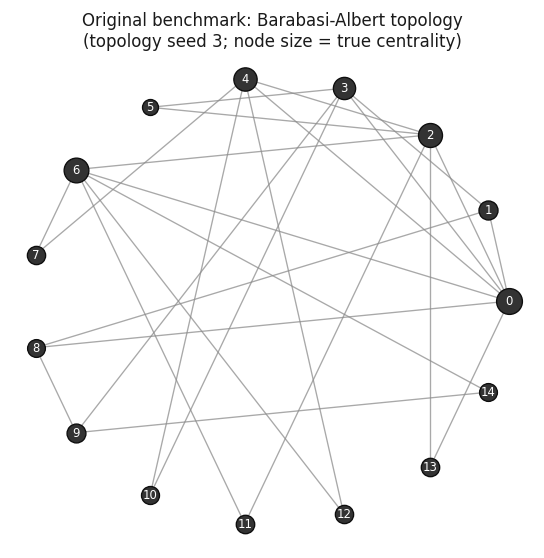

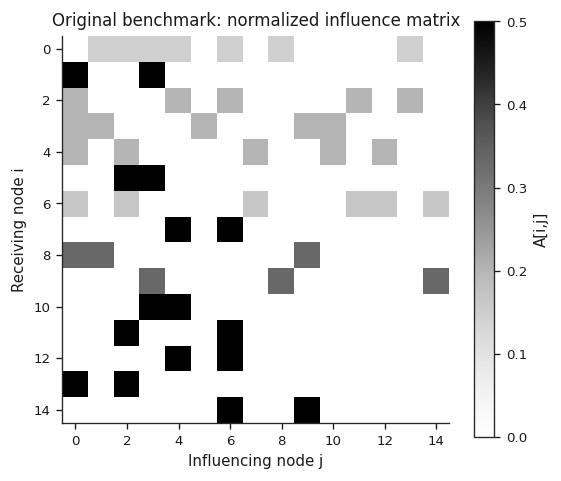

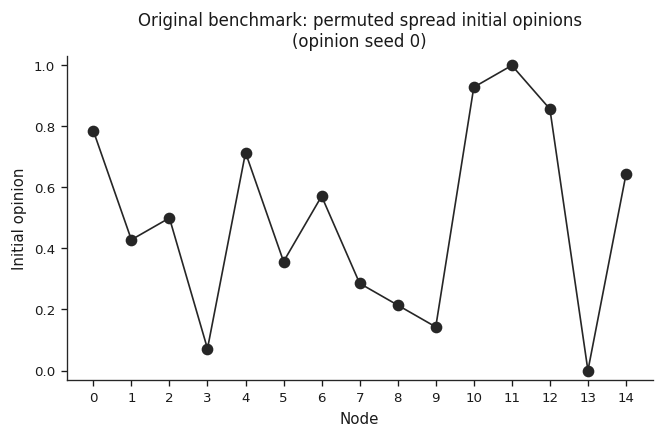

,family,n_nodes,graph_model,ba_m,canonical_topology_seed,canonical_opinion_seed,x0_min,x0_max,x0_mean,x0_std,max_true_centrality
0,barabasi_albert_spread,15,barabasi_albert,2,3,0,0.0,1.0,0.5,0.308607,0.145087


In [22]:
canonical_original_id = (
    "unstructured__laplacian__topo03__x00"
)
canonical_original = load_environment_definition(
    canonical_original_id
)

A_original = np.asarray(
    canonical_original["A"],
    dtype=float,
)
x0_original = np.asarray(
    canonical_original["x0"],
    dtype=float,
)
v_original = np.asarray(
    canonical_original["v_true"],
    dtype=float,
)

# Deterministic circular positions avoid any dependence on a graph-layout package.
angles = np.linspace(
    0.0,
    2.0 * np.pi,
    len(x0_original),
    endpoint=False,
)
positions = np.column_stack(
    [
        np.cos(angles),
        np.sin(angles),
    ]
)

# Draw each structural edge once. BA construction is structurally undirected,
# although row normalization can make A_ij and A_ji numerically different.
structural = (
    (A_original > 0)
    | (A_original.T > 0)
)

fig, ax = plt.subplots(figsize=(5.6, 5.3))

for i in range(len(x0_original)):
    for j in range(i + 1, len(x0_original)):
        if not structural[i, j]:
            continue

        ax.plot(
            [
                positions[i, 0],
                positions[j, 0],
            ],
            [
                positions[i, 1],
                positions[j, 1],
            ],
            linewidth=0.8,
            color=(
                "0.55"
                if PLOT_STYLE == "paper_bw"
                else None
            ),
            alpha=0.75,
            zorder=1,
        )

centrality_scaled = (
    v_original
    / max(v_original.max(), 1e-12)
)

for node in range(len(x0_original)):
    ax.scatter(
        [positions[node, 0]],
        [positions[node, 1]],
        s=70 + 170 * centrality_scaled[node],
        facecolors=(
            "0.20"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
        edgecolors=(
            "0.05"
            if PLOT_STYLE == "paper_bw"
            else None
        ),
        linewidths=0.8,
        zorder=2,
    )
    ax.text(
        positions[node, 0],
        positions[node, 1],
        str(node),
        ha="center",
        va="center",
        fontsize=7,
        color=(
            "1.0"
            if PLOT_STYLE == "paper_bw"
            else "0.1"
        ),
        zorder=3,
    )

ax.set_title(
    "Original benchmark: Barabasi-Albert topology\n"
    "(topology seed 3; node size = true centrality)"
)
ax.set_axis_off()

save_figure(
    fig,
    "10_original_barabasi_albert_topology",
)
plt.show()
plt.close(fig)

# Adjacency matrix is useful because the model itself uses normalized weights.
fig, ax = plt.subplots(figsize=(5.2, 4.5))
image = ax.imshow(
    A_original,
    aspect="equal",
    interpolation="nearest",
    cmap=(
        "Greys"
        if PLOT_STYLE == "paper_bw"
        else "viridis"
    ),
)
ax.set_xlabel("Influencing node j")
ax.set_ylabel("Receiving node i")
ax.set_title(
    "Original benchmark: normalized influence matrix"
)
fig.colorbar(
    image,
    ax=ax,
    label="A[i,j]",
)

save_figure(
    fig,
    "10_original_barabasi_albert_adjacency",
)
plt.show()
plt.close(fig)

# Exact canonical spread-opinion initialization.
fig, ax = plt.subplots(figsize=(6.3, 3.5))
ax.plot(
    np.arange(len(x0_original)),
    x0_original,
    marker="o",
    linestyle="-",
    linewidth=1.0,
    color=(
        "0.15"
        if PLOT_STYLE == "paper_bw"
        else None
    ),
)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("Node")
ax.set_ylabel("Initial opinion")
ax.set_xticks(np.arange(len(x0_original)))
ax.set_title(
    "Original benchmark: permuted spread initial opinions\n"
    "(opinion seed 0)"
)

save_figure(
    fig,
    "10_original_spread_initial_opinions",
)
plt.show()
plt.close(fig)

original_definition_summary = pd.DataFrame(
    [
        {
            "family": "barabasi_albert_spread",
            "n_nodes": len(x0_original),
            "graph_model": "barabasi_albert",
            "ba_m": 2,
            "canonical_topology_seed": 3,
            "canonical_opinion_seed": 0,
            "x0_min": float(x0_original.min()),
            "x0_max": float(x0_original.max()),
            "x0_mean": float(x0_original.mean()),
            "x0_std": float(x0_original.std()),
            "max_true_centrality": float(v_original.max()),
        }
    ]
)

display(original_definition_summary)

## Schematic topology plots for the structured families

The following plots are **schematic views** of the family construction.
They are intended to explain the topology families visually, not to display every exact edge weight.

For the broadcaster families, the two top nodes are the hubs and the bottom nodes are the leaves.  
For the HK families, the two central nodes are the inter-cluster bridge hubs.


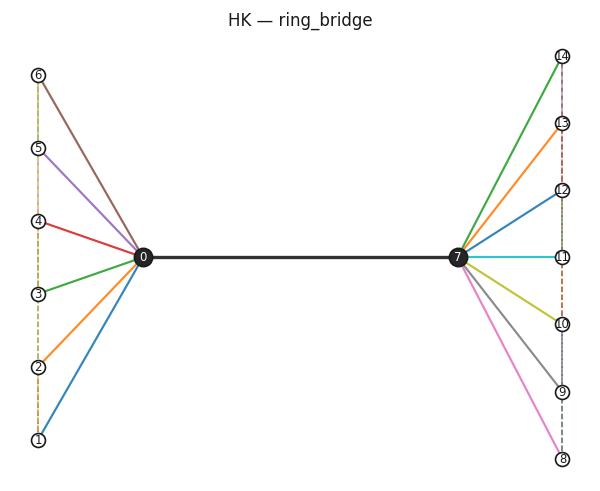

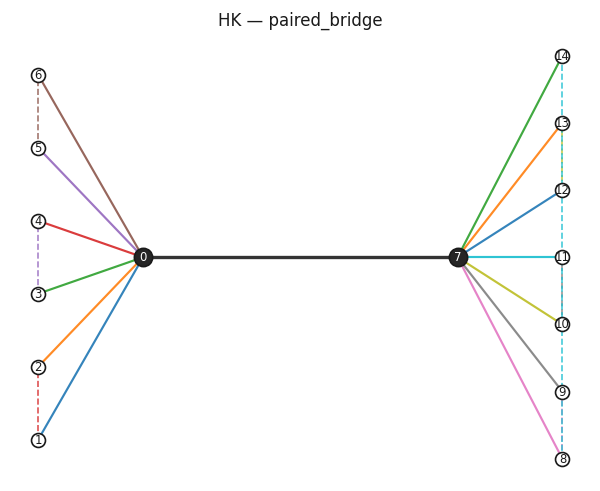

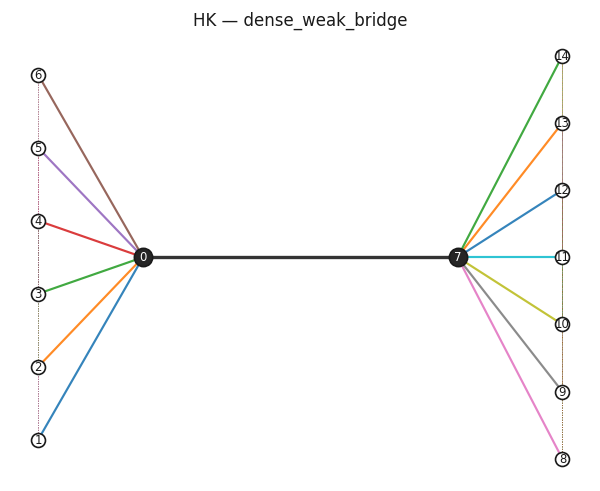

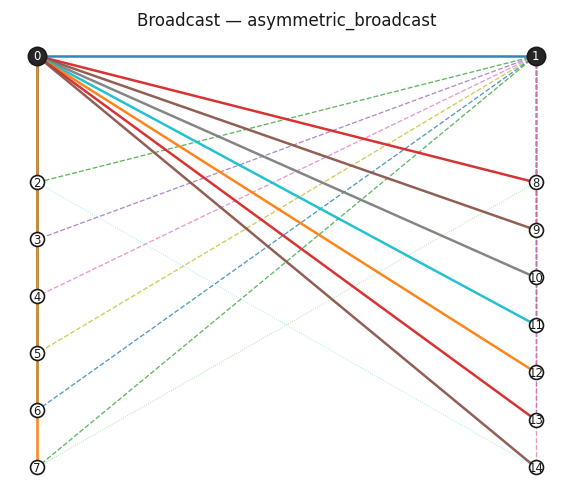

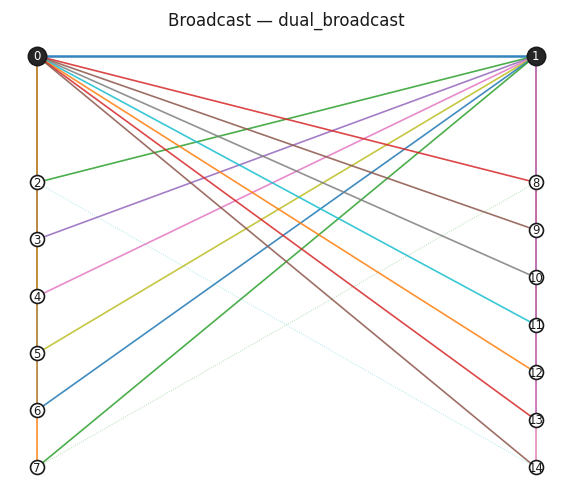

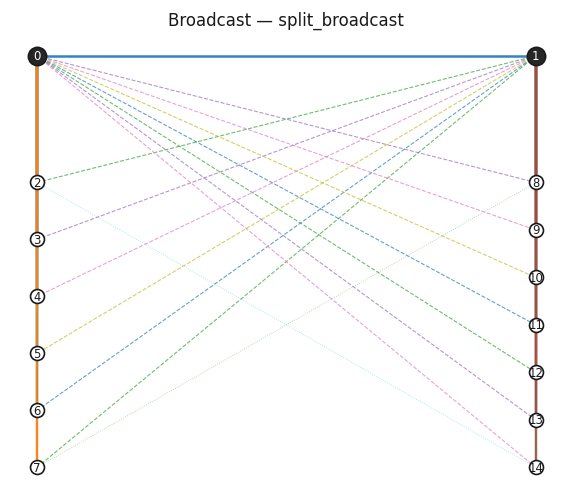

In [23]:
def draw_line(ax, p1, p2, *, linewidth=1.0, linestyle="-", color=None, alpha=1.0):
    xs = [p1[0], p2[0]]
    ys = [p1[1], p2[1]]
    ax.plot(xs, ys, linewidth=linewidth, linestyle=linestyle, color=color, alpha=alpha, zorder=1)


def hk_positions():
    pos = {}
    pos[0] = (-1.05, 0.0)
    pos[7] = (1.05, 0.0)

    left_leaves = [1, 2, 3, 4, 5, 6]
    right_leaves = [8, 9, 10, 11, 12, 13, 14]

    left_y = np.linspace(-0.95, 0.95, len(left_leaves))
    right_y = np.linspace(-1.05, 1.05, len(right_leaves))

    for idx, node in enumerate(left_leaves):
        pos[node] = (-1.75, float(left_y[idx]))
    for idx, node in enumerate(right_leaves):
        pos[node] = (1.75, float(right_y[idx]))

    return pos


def broadcaster_positions():
    pos = {
        0: (-0.95, 0.95),
        1: (0.95, 0.95),
    }

    leaves_left = list(range(2, 8))
    leaves_right = list(range(8, 15))

    y_left = np.linspace(0.35, -1.0, len(leaves_left))
    y_right = np.linspace(0.35, -1.0, len(leaves_right))

    for idx, node in enumerate(leaves_left):
        pos[node] = (-0.95, float(y_left[idx]))
    for idx, node in enumerate(leaves_right):
        pos[node] = (0.95, float(y_right[idx]))

    return pos


def draw_nodes(ax, pos, *, hubs, labels=True):
    for node, (x0, y0) in pos.items():
        is_hub = node in hubs
        if PLOT_STYLE == "paper_bw":
            facecolor = "0.15" if is_hub else "1.0"
            edgecolor = "0.1"
        else:
            facecolor = None
            edgecolor = None

        ax.scatter(
            [x0],
            [y0],
            s=120 if is_hub else 70,
            marker="o",
            facecolors=facecolor,
            edgecolors=edgecolor,
            linewidths=1.0,
            zorder=2,
        )
        if labels:
            ax.text(
                x0,
                y0,
                str(node),
                ha="center",
                va="center",
                fontsize=7,
                color=("1.0" if (PLOT_STYLE == "paper_bw" and is_hub) else "0.1"),
                zorder=3,
            )


def draw_hk_family(ax, family):
    pos = hk_positions()
    draw_line(
        ax,
        pos[0],
        pos[7],
        linewidth=2.0,
        linestyle="-",
        color=("0.2" if PLOT_STYLE == "paper_bw" else None),
    )

    left_cluster = [0, 1, 2, 3, 4, 5, 6]
    right_cluster = [7, 8, 9, 10, 11, 12, 13, 14]

    for node in left_cluster:
        if node != 0:
            draw_line(ax, pos[0], pos[node], linewidth=1.3, alpha=0.9)
    for node in right_cluster:
        if node != 7:
            draw_line(ax, pos[7], pos[node], linewidth=1.3, alpha=0.9)

    if family == "ring_bridge":
        left_leaves = [1, 2, 3, 4, 5, 6]
        right_leaves = [8, 9, 10, 11, 12, 13, 14]
        for group in [left_leaves, right_leaves]:
            seq = group + [group[0]]
            for a, b in zip(seq[:-1], seq[1:]):
                draw_line(ax, pos[a], pos[b], linewidth=0.9, linestyle="--", alpha=0.8)

    elif family == "paired_bridge":
        pairs = [(1, 2), (3, 4), (5, 6), (8, 9), (10, 11), (12, 13)]
        for a, b in pairs:
            draw_line(ax, pos[a], pos[b], linewidth=1.0, linestyle="--", alpha=0.8)
        draw_line(ax, pos[14], pos[8], linewidth=1.0, linestyle="--", alpha=0.8)

    elif family == "dense_weak_bridge":
        left_leaves = [1, 2, 3, 4, 5, 6]
        right_leaves = [8, 9, 10, 11, 12, 13, 14]
        for group in [left_leaves, right_leaves]:
            for i, a in enumerate(group):
                for b in group[i + 1:]:
                    draw_line(ax, pos[a], pos[b], linewidth=0.55, linestyle=":", alpha=0.55)

    draw_nodes(ax, pos, hubs={0, 7})
    ax.set_title(f"HK — {family}")
    ax.set_axis_off()


def draw_broadcast_family(ax, family):
    pos = broadcaster_positions()

    leaves = list(range(2, 15))
    group_a = list(range(2, 8))
    group_b = list(range(8, 15))

    draw_line(ax, pos[0], pos[1], linewidth=1.5, linestyle="-", alpha=0.9)

    for leaf in leaves:
        if family == "dual_broadcast":
            draw_line(ax, pos[0], pos[leaf], linewidth=1.0, alpha=0.85)
            draw_line(ax, pos[1], pos[leaf], linewidth=1.0, alpha=0.85)

        elif family == "asymmetric_broadcast":
            draw_line(ax, pos[0], pos[leaf], linewidth=1.5, alpha=0.95)
            draw_line(ax, pos[1], pos[leaf], linewidth=0.8, linestyle="--", alpha=0.75)

        elif family == "split_broadcast":
            primary_left = leaf in group_a
            if primary_left:
                draw_line(ax, pos[0], pos[leaf], linewidth=1.45, alpha=0.95)
                draw_line(ax, pos[1], pos[leaf], linewidth=0.65, linestyle="--", alpha=0.7)
            else:
                draw_line(ax, pos[1], pos[leaf], linewidth=1.45, alpha=0.95)
                draw_line(ax, pos[0], pos[leaf], linewidth=0.65, linestyle="--", alpha=0.7)

    ring_order = leaves + [leaves[0]]
    for a, b in zip(ring_order[:-1], ring_order[1:]):
        draw_line(ax, pos[a], pos[b], linewidth=0.5, linestyle=":", alpha=0.45)

    draw_nodes(ax, pos, hubs={0, 1})
    ax.set_title(f"Broadcast — {family}")
    ax.set_axis_off()


for family in ["ring_bridge", "paired_bridge", "dense_weak_bridge"]:
    fig, ax = plt.subplots(figsize=(6.2, 4.8))
    draw_hk_family(ax, family)
    save_figure(fig, f"11_hk_schematic_{family}")
    plt.show()
    plt.close(fig)

for family in ["asymmetric_broadcast", "dual_broadcast", "split_broadcast"]:
    fig, ax = plt.subplots(figsize=(5.9, 4.9))
    draw_broadcast_family(ax, family)
    save_figure(fig, f"11_broadcast_schematic_{family}")
    plt.show()
    plt.close(fig)

## Canonical initial-opinion profiles for the structured families

To complement the topology schematics, the next plots show the **initial opinions** used by the canonical `env00` instance of each structured family.
This makes the mechanism easier to interpret together with the schematics.


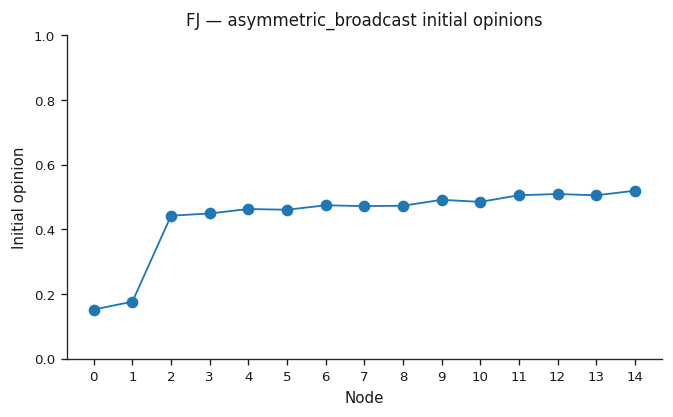

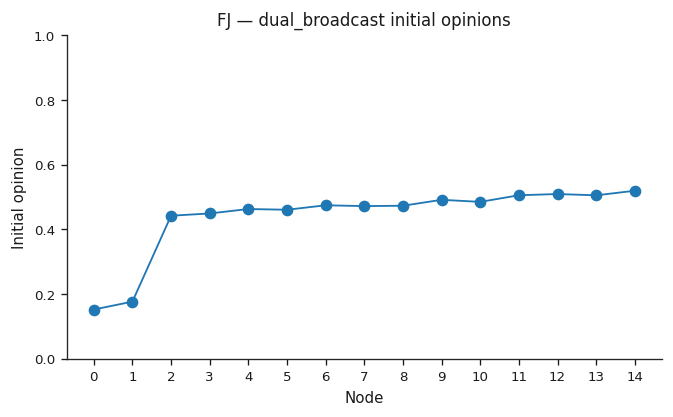

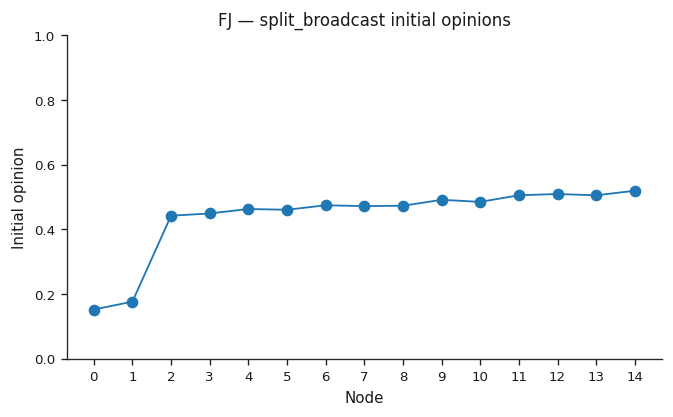

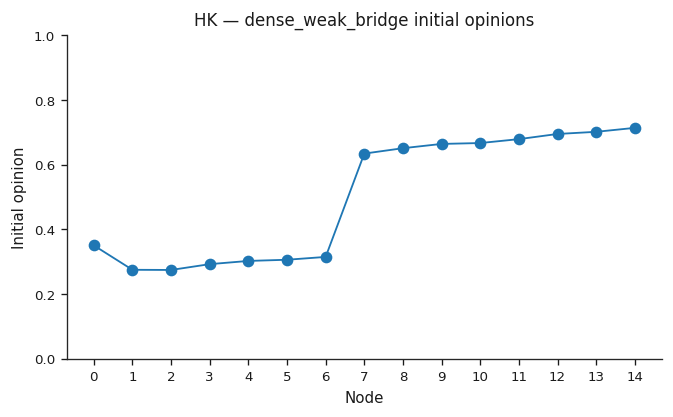

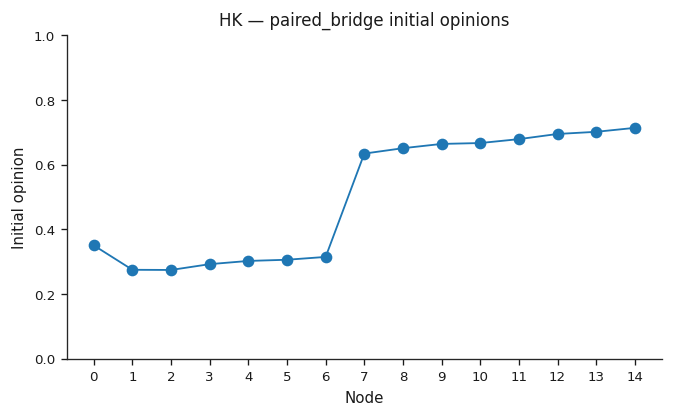

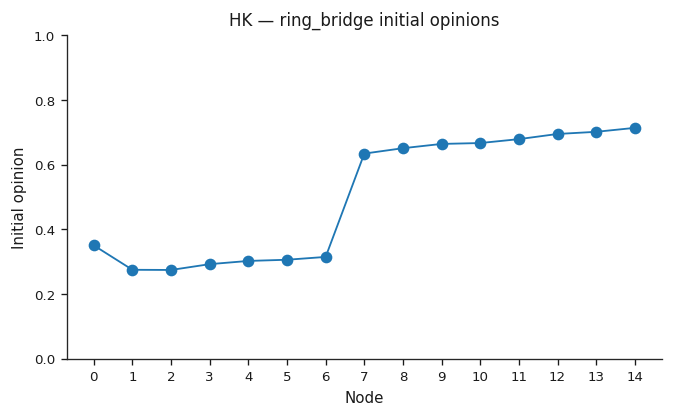

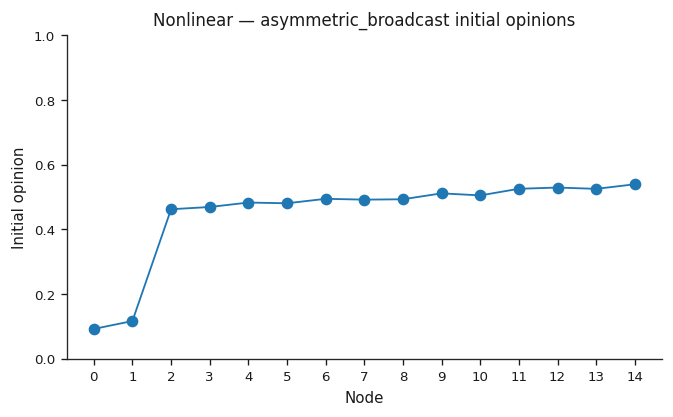

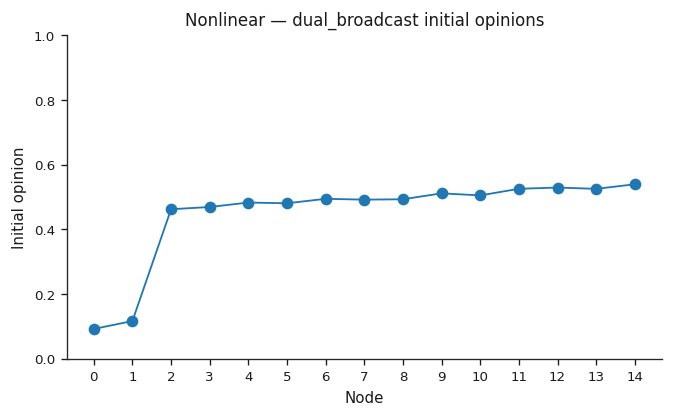

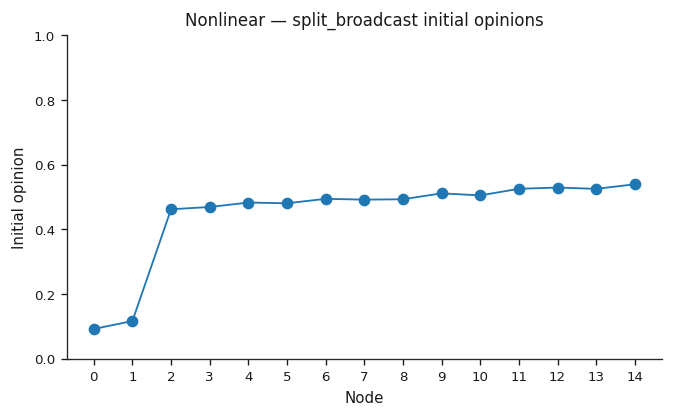

In [24]:
def canonical_structured_environment_id(dynamics, family):
    return f"structured__{dynamics}__{family}__env00"


def canonical_initial_state(environment_id):
    cache_dir = Path(ENV_INDEX[environment_id]["cache_dir"])
    baseline = load_baseline_rollout(environment_id, "no_control")
    return np.asarray(baseline["states"][0], dtype=float)


structured_pairs = [
    ("friedkinjohnsen", "asymmetric_broadcast"),
    ("friedkinjohnsen", "dual_broadcast"),
    ("friedkinjohnsen", "split_broadcast"),
    ("hegselmannkrause", "dense_weak_bridge"),
    ("hegselmannkrause", "paired_bridge"),
    ("hegselmannkrause", "ring_bridge"),
    ("nonlinearinfluence", "asymmetric_broadcast"),
    ("nonlinearinfluence", "dual_broadcast"),
    ("nonlinearinfluence", "split_broadcast"),
]

for dynamics, family in structured_pairs:
    environment_id = canonical_structured_environment_id(dynamics, family)
    x0 = canonical_initial_state(environment_id)

    fig, ax = plt.subplots(figsize=(6.4, 3.5))
    ax.plot(
        np.arange(len(x0)),
        x0,
        marker="o",
        linestyle="-",
        linewidth=1.1,
    )
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Node")
    ax.set_ylabel("Initial opinion")
    ax.set_title(f"{DYNAMICS_LABELS[dynamics]} — {family} initial opinions")
    ax.set_xticks(np.arange(len(x0)))

    save_figure(fig, f"12_initial_opinions_{dynamics}_{family}")
    plt.show()
    plt.close(fig)

## Paper-ready tables

This section exports a standardized set of manuscript-facing tables. The same core schema is used by the abundant-data notebook so the two regimes can later be compared or joined directly.

The primary table reports the **complete absolute policy picture** (no control, uniform, learned, and true-graph reference) together with the paired learned-controller effects. Additional tables preserve structured-family detail, trajectory-level effects, identification quality, prediction-versus-control correlations, and mechanism-targeting behavior.

For the generic $5\times5$ benchmark, confidence intervals use the crossed topology/opinion bootstrap defined above. Structured environment and family intervals use Student-$t$ intervals over independent environment realizations.

In [25]:
PAPER_TABLE_DIR = RESULTS_DIR / "paper_tables"
PAPER_TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Standardized aliases used only by the paper-table layer.
if "learned_minus_no_control_final" not in env_level_df.columns:
    env_level_df["learned_minus_no_control_final"] = (
        env_level_df["learned_final_mean"] - env_level_df["no_control_final_mean"]
    )
if "true_graph_minus_uniform_final" not in env_level_df.columns:
    env_level_df["true_graph_minus_uniform_final"] = (
        env_level_df["true_graph_final_mean"] - env_level_df["uniform_final_mean"]
    )


def _ci_fields(group: pd.DataFrame, value_col: str, prefix: str) -> dict[str, Any]:
    mean, low, high, method = mean_ci_for_group(group, value_col)
    return {
        f"{prefix}_mean": mean,
        f"{prefix}_ci_low": low,
        f"{prefix}_ci_high": high,
        f"{prefix}_ci_method": method,
    }


def _complete_performance_row(
    group: pd.DataFrame,
    *,
    scenario_class: str,
    dynamics: str,
    family: str | None = None,
) -> dict[str, Any]:
    row: dict[str, Any] = {
        "regime": "single_shot",
        "scenario_class": scenario_class,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "family": family,
        "n_environments": int(len(group)),
    }

    for label, col in [
        ("no_control", "no_control_final_mean"),
        ("uniform", "uniform_final_mean"),
        ("learned", "learned_final_mean"),
        ("true_graph", "true_graph_final_mean"),
        ("learned_minus_uniform", "learned_gap_final"),
        ("learned_minus_true_graph", "learned_minus_true_graph_final"),
        ("learned_minus_no_control", "learned_minus_no_control_final"),
        ("true_graph_minus_uniform", "true_graph_minus_uniform_final"),
    ]:
        row.update(_ci_fields(group, col, label))

    row["environment_win_rate_vs_uniform"] = float((group["learned_gap_final"] > 0).mean())
    row["environment_win_rate_vs_true_graph"] = float(
        (group["learned_minus_true_graph_final"] > 0).mean()
    )
    row["mean_learning_seed_std_final"] = float(group["learned_final_mean_seed_std"].mean())
    row["mean_prediction_mae_ratio"] = float(group["final_fit_model_over_identity"].mean())
    return row


# ---------------------------------------------------------------------------
# 1) Complete absolute performance + paired effects by dynamics/scenario.
# ---------------------------------------------------------------------------
performance_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"], sort=False
):
    performance_rows.append(
        _complete_performance_row(
            group,
            scenario_class=scenario_class,
            dynamics=dynamics,
        )
    )

paper_policy_performance_df = pd.DataFrame(performance_rows)
scenario_order = {"unstructured_random": 0, "structured_mechanism": 1}
dynamics_order_map = {
    d: i for i, d in enumerate(DYNAMICS_ORDER + STRUCTURED_ORDER)
}
paper_policy_performance_df["_scenario_order"] = paper_policy_performance_df["scenario_class"].map(scenario_order)
paper_policy_performance_df["_dynamics_order"] = paper_policy_performance_df["dynamics"].map(dynamics_order_map)
paper_policy_performance_df = (
    paper_policy_performance_df
    .sort_values(["_scenario_order", "_dynamics_order"])
    .drop(columns=["_scenario_order", "_dynamics_order"])
    .reset_index(drop=True)
)
paper_policy_performance_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_policy_performance_by_dynamics.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 2) Complete structured-family performance (all four policies + effects).
# ---------------------------------------------------------------------------
structured_family_rows = []
for (dynamics, family), group in env_level_df[
    env_level_df["scenario_class"] == "structured_mechanism"
].groupby(["dynamics", "family"], sort=False):
    structured_family_rows.append(
        _complete_performance_row(
            group,
            scenario_class="structured_mechanism",
            dynamics=dynamics,
            family=family,
        )
    )
paper_structured_family_df = pd.DataFrame(structured_family_rows)
paper_structured_family_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_structured_families.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 3) Paired-effect table, including trajectory-level improvement.
# ---------------------------------------------------------------------------
paired_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"], sort=False
):
    row = {
        "regime": "single_shot",
        "scenario_class": scenario_class,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "n_environments": int(len(group)),
    }
    row.update(_ci_fields(group, "learned_gap_final", "learned_minus_uniform_final"))
    row.update(_ci_fields(group, "learned_gap_path", "learned_minus_uniform_path"))
    row.update(_ci_fields(group, "learned_minus_true_graph_final", "learned_minus_true_graph_final"))
    row["environment_win_rate_vs_uniform"] = float((group["learned_gap_final"] > 0).mean())
    row["environment_win_rate_vs_true_graph"] = float(
        (group["learned_minus_true_graph_final"] > 0).mean()
    )
    paired_rows.append(row)
paper_paired_effects_df = pd.DataFrame(paired_rows)
paper_paired_effects_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_paired_effects_by_dynamics.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 4) Identification quality and learning-seed variability.
# ---------------------------------------------------------------------------
identification_rows = []
for (scenario_class, dynamics), group in env_level_df.groupby(
    ["scenario_class", "dynamics"], sort=False
):
    ratio_mean, ratio_low, ratio_high, ratio_method = mean_ci_for_group(
        group, "final_fit_model_over_identity"
    )
    seed_std_mean, seed_std_low, seed_std_high, seed_std_method = mean_ci_for_group(
        group, "learned_final_mean_seed_std"
    )
    path_seed_std_mean, path_seed_std_low, path_seed_std_high, _ = mean_ci_for_group(
        group, "learned_path_seed_std"
    )
    identification_rows.append({
        "regime": "single_shot",
        "scenario_class": scenario_class,
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "n_environments": int(len(group)),
        "prediction_mae_ratio_mean": ratio_mean,
        "prediction_mae_ratio_ci_low": ratio_low,
        "prediction_mae_ratio_ci_high": ratio_high,
        "prediction_mae_ratio_ci_method": ratio_method,
        "final_performance_seed_std_mean": seed_std_mean,
        "final_performance_seed_std_ci_low": seed_std_low,
        "final_performance_seed_std_ci_high": seed_std_high,
        "path_performance_seed_std_mean": path_seed_std_mean,
        "path_performance_seed_std_ci_low": path_seed_std_low,
        "path_performance_seed_std_ci_high": path_seed_std_high,
        "seed_variability_ci_method": seed_std_method,
    })
paper_identification_df = pd.DataFrame(identification_rows)
paper_identification_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_identification.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 5) Prediction quality versus control improvement (Spearman rank tests).
# ---------------------------------------------------------------------------
def _paper_spearman_row(label: str, group: pd.DataFrame) -> dict[str, Any]:
    subset = group[["final_fit_model_over_identity", "learned_gap_final"]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if (
        len(subset) < 3
        or subset["final_fit_model_over_identity"].nunique() < 2
        or subset["learned_gap_final"].nunique() < 2
    ):
        return {"group": label, "n": len(subset), "rho": np.nan, "p_value": np.nan}
    result = spearmanr(
        subset["final_fit_model_over_identity"], subset["learned_gap_final"]
    )
    return {
        "group": label,
        "n": int(len(subset)),
        "rho": float(result.statistic),
        "p_value": float(result.pvalue),
    }

corr_rows = [_paper_spearman_row("all", env_level_df)]
for scenario_class, group in env_level_df.groupby("scenario_class", sort=False):
    corr_rows.append(_paper_spearman_row(scenario_class, group))
for dynamics, group in env_level_df.groupby("dynamics", sort=False):
    corr_rows.append(_paper_spearman_row(f"dynamics:{dynamics}", group))
paper_prediction_control_corr_df = pd.DataFrame(corr_rows)
paper_prediction_control_corr_df.insert(0, "regime", "single_shot")
paper_prediction_control_corr_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_prediction_control_spearman.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# 6) Structured mechanism targeting from the cached full rollouts.
#    HK bridge hubs are nodes {0, 7}; FJ/nonlinear broadcaster hubs are {0, 1}.
# ---------------------------------------------------------------------------
def _controlled_hub_fraction(actions: np.ndarray, hubs: set[int]) -> float:
    actions = np.asarray(actions, dtype=float)
    if actions.ndim != 2:
        return np.nan
    total = float(actions.sum())
    if total <= 1e-12:
        return np.nan
    hub_idx = np.array(sorted(hubs), dtype=int)
    return float(actions[:, hub_idx].sum() / total)

hub_nodes_by_dynamics = {
    "hegselmannkrause": {0, 7},
    "friedkinjohnsen": {0, 1},
    "nonlinearinfluence": {0, 1},
}

single_target_env_rows = []
structured_ids = env_level_df.loc[
    env_level_df["scenario_class"] == "structured_mechanism",
    ["environment_id", "dynamics", "family"],
].drop_duplicates()

for env_row in structured_ids.itertuples(index=False):
    hubs = hub_nodes_by_dynamics[env_row.dynamics]
    learned_fractions = []
    for learning_seed in LEARNING_SEEDS:
        rollout = load_learned_rollout(env_row.environment_id, learning_seed)
        learned_fractions.append(_controlled_hub_fraction(rollout["actions"], hubs))

    uniform_rollout = load_baseline_rollout(env_row.environment_id, "uniform")
    true_graph_rollout = load_baseline_rollout(env_row.environment_id, "true_graph")

    single_target_env_rows.append({
        "environment_id": env_row.environment_id,
        "dynamics": env_row.dynamics,
        "family": env_row.family,
        "learned_hub_budget_fraction": float(np.nanmean(learned_fractions)),
        "uniform_hub_budget_fraction": _controlled_hub_fraction(uniform_rollout["actions"], hubs),
        "true_graph_hub_budget_fraction": _controlled_hub_fraction(true_graph_rollout["actions"], hubs),
    })

single_target_env_df = pd.DataFrame(single_target_env_rows)
single_target_env_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_structured_targeting_environment_level.csv",
    index=False,
)

target_family_rows = []
for (dynamics, family), group in single_target_env_df.groupby(["dynamics", "family"], sort=False):
    row = {
        "regime": "single_shot",
        "dynamics": dynamics,
        "dynamics_label": DYNAMICS_LABELS.get(dynamics, dynamics),
        "family": family,
        "n_environments": int(len(group)),
    }
    for label, col in [
        ("uniform", "uniform_hub_budget_fraction"),
        ("learned", "learned_hub_budget_fraction"),
        ("true_graph", "true_graph_hub_budget_fraction"),
    ]:
        mean, low, high = student_t_mean_ci(group[col].to_numpy(dtype=float))
        row[f"{label}_mean"] = mean
        row[f"{label}_ci_low"] = low
        row[f"{label}_ci_high"] = high
    target_family_rows.append(row)
paper_targeting_df = pd.DataFrame(target_family_rows)
paper_targeting_df.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_structured_targeting.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# Display compact manuscript views and LaTeX previews.
# ---------------------------------------------------------------------------
main_cols = [
    "scenario_class", "dynamics_label", "n_environments",
    "no_control_mean", "uniform_mean", "learned_mean", "true_graph_mean",
    "learned_minus_uniform_mean", "learned_minus_uniform_ci_low", "learned_minus_uniform_ci_high",
    "environment_win_rate_vs_uniform", "learned_minus_true_graph_mean",
]
print("PAPER TABLE — single-shot complete policy performance")
display(paper_policy_performance_df[main_cols].round(5))

print("\nPAPER TABLE — single-shot structured families")
display(paper_structured_family_df[main_cols + ["family"]].round(5))

print("\nPAPER TABLE — single-shot identification")
display(paper_identification_df.round(5))

print("\nPAPER TABLE — single-shot prediction/control correlations")
display(paper_prediction_control_corr_df.round(5))

print("\nPAPER TABLE — single-shot structured mechanism targeting")
display(paper_targeting_df.round(5))

print("\nLaTeX preview — single-shot complete policy performance")
print(
    paper_policy_performance_df[main_cols]
    .round(4)
    .to_latex(index=False, escape=True)
)

paper_table_manifest_single = pd.DataFrame([
    {"file": "paper_table_single_shot_policy_performance_by_dynamics.csv", "purpose": "Main absolute four-policy performance plus paired final effects"},
    {"file": "paper_table_single_shot_structured_families.csv", "purpose": "All four policies and paired effects for each of the nine structured families"},
    {"file": "paper_table_single_shot_paired_effects_by_dynamics.csv", "purpose": "Final and trajectory-level paired effects with win rates"},
    {"file": "paper_table_single_shot_identification.csv", "purpose": "Prediction MAE ratio and learning-seed variability"},
    {"file": "paper_table_single_shot_prediction_control_spearman.csv", "purpose": "Prediction-quality versus control-improvement rank correlations"},
    {"file": "paper_table_single_shot_structured_targeting.csv", "purpose": "Mechanism-hub budget fractions by structured family"},
])
paper_table_manifest_single.to_csv(
    PAPER_TABLE_DIR / "paper_table_single_shot_manifest.csv", index=False
)
print("\nPaper tables written to:", PAPER_TABLE_DIR)
display(paper_table_manifest_single)


PAPER TABLE — single-shot complete policy performance


,scenario_class,dynamics_label,n_environments,no_control_mean,uniform_mean,learned_mean,true_graph_mean,learned_minus_uniform_mean,learned_minus_uniform_ci_low,learned_minus_uniform_ci_high,environment_win_rate_vs_uniform,learned_minus_true_graph_mean
0,unstructured_random,Linear,25,0.54103,0.69365,0.76599,0.81645,0.07234,0.04534,0.10475,1.00,-0.05045
1,unstructured_random,COCA,25,0.54861,0.73654,0.77307,0.78185,0.03654,0.02485,0.05025,1.00,-0.00878
2,unstructured_random,Repulsion,25,0.52092,0.61094,0.72017,0.73479,0.10924,0.05929,0.16475,0.96,-0.01461
3,unstructured_random,HK,25,0.51544,0.68555,0.79249,0.82106,0.10694,0.07719,0.14311,1.00,-0.02857
4,unstructured_random,FJ,25,0.54037,0.60878,0.68437,0.69559,0.07558,0.05066,0.10018,1.00,-0.01122
5,unstructured_random,Nonlinear,25,0.54024,0.69313,0.82014,0.84473,0.12701,0.09587,0.16080,1.00,-0.02458
6,structured_mechanism,HK,15,0.50278,0.66980,0.87652,0.89542,0.20672,0.20412,0.20932,1.00,-0.01890
7,structured_mechanism,FJ,15,0.31478,0.41721,0.61128,0.61384,0.19407,0.18927,0.19887,1.00,-0.00256
8,structured_mechanism,Nonlinear,15,0.29227,0.52762,0.86499,0.86558,0.33737,0.33168,0.34306,1.00,-0.00058



PAPER TABLE — single-shot structured families


,scenario_class,dynamics_label,n_environments,no_control_mean,uniform_mean,learned_mean,true_graph_mean,learned_minus_uniform_mean,learned_minus_uniform_ci_low,learned_minus_uniform_ci_high,environment_win_rate_vs_uniform,learned_minus_true_graph_mean,family
0,structured_mechanism,FJ,5,0.31169,0.41459,0.61965,0.62277,0.20506,0.20200,0.20813,1.0,-0.00312,asymmetric_broadcast
1,structured_mechanism,FJ,5,0.31635,0.41853,0.60506,0.60922,0.18653,0.18114,0.19192,1.0,-0.00416,dual_broadcast
2,structured_mechanism,FJ,5,0.31632,0.41851,0.60913,0.60953,0.19062,0.18965,0.19158,1.0,-0.00041,split_broadcast
3,structured_mechanism,HK,5,0.50302,0.67034,0.88183,0.89941,0.21149,0.20919,0.21379,1.0,-0.01758,dense_weak_bridge
4,structured_mechanism,HK,5,0.50266,0.66967,0.87642,0.89641,0.20675,0.20223,0.21126,1.0,-0.02000,paired_bridge
5,structured_mechanism,HK,5,0.50267,0.66938,0.87131,0.89044,0.20193,0.19971,0.20415,1.0,-0.01914,ring_bridge
6,structured_mechanism,Nonlinear,5,0.28941,0.52571,0.87698,0.87813,0.35127,0.34870,0.35384,1.0,-0.00115,asymmetric_broadcast
7,structured_mechanism,Nonlinear,5,0.29380,0.52864,0.85907,0.85924,0.33043,0.32914,0.33172,1.0,-0.00017,dual_broadcast
8,structured_mechanism,Nonlinear,5,0.29361,0.52851,0.85894,0.85935,0.33042,0.32865,0.33219,1.0,-0.00042,split_broadcast



PAPER TABLE — single-shot identification


...

,regime,group,n,rho,p_value
0,single_shot,all,195,-0.62026,0.00000
1,single_shot,structured_mechanism,45,-0.59934,0.00001
2,single_shot,unstructured_random,150,-0.30000,0.00019
3,single_shot,dynamics:friedkinjohnsen,40,-0.85103,0.00000
4,single_shot,dynamics:hegselmannkrause,40,-0.71670,0.00000
5,single_shot,dynamics:nonlinearinfluence,40,-0.89006,0.00000
6,single_shot,dynamics:coca,25,0.26385,0.20252
7,single_shot,dynamics:laplacian,25,-0.84462,0.00000
8,single_shot,dynamics:repulsion,25,-0.25000,0.22810



PAPER TABLE — single-shot structured mechanism targeting


,regime,dynamics,dynamics_label,family,n_environments,uniform_mean,uniform_ci_low,uniform_ci_high,learned_mean,learned_ci_low,learned_ci_high,true_graph_mean,true_graph_ci_low,true_graph_ci_high
0,single_shot,friedkinjohnsen,FJ,asymmetric_broadcast,5,0.13333,0.13333,0.13333,0.97427,0.95470,0.99383,1.0,1.0,1.0
1,single_shot,friedkinjohnsen,FJ,dual_broadcast,5,0.13333,0.13333,0.13333,0.98667,0.96868,1.00465,1.0,1.0,1.0
2,single_shot,friedkinjohnsen,FJ,split_broadcast,5,0.13333,0.13333,0.13333,1.00000,1.00000,1.00000,1.0,1.0,1.0
3,single_shot,hegselmannkrause,HK,dense_weak_bridge,5,0.13333,0.13333,0.13333,0.88187,0.86748,0.89627,1.0,1.0,1.0
4,single_shot,hegselmannkrause,HK,paired_bridge,5,0.13333,0.13333,0.13333,0.86561,0.83640,0.89482,1.0,1.0,1.0
5,single_shot,hegselmannkrause,HK,ring_bridge,5,0.13333,0.13333,0.13333,0.86725,0.85526,0.87924,1.0,1.0,1.0
6,single_shot,nonlinearinfluence,Nonlinear,asymmetric_broadcast,5,0.13333,0.13333,0.13333,1.00000,1.00000,1.00000,1.0,1.0,1.0
7,single_shot,nonlinearinfluence,Nonlinear,dual_broadcast,5,0.13333,0.13333,0.13333,1.00000,1.00000,1.00000,1.0,1.0,1.0
8,single_shot,nonlinearinfluence,Nonlinear,split_broadcast,5,0.13333,0.13333,0.13333,1.00000,1.00000,1.00000,1.0,1.0,1.0



LaTeX preview — single-shot complete policy performance
\begin{tabular}{llrrrrrrrrrr}
\toprule
scenario\_class & dynamics\_label & n\_environments & no\_control\_mean & uniform\_mean & learned\_mean & true\_graph\_mean & learned\_minus\_uniform\_mean & learned\_minus\_uniform\_ci\_low & learned\_minus\_uniform\_ci\_high & environment\_win\_rate\_vs\_uniform & learned\_minus\_true\_graph\_mean \\
\midrule
unstructured\_random & Linear & 25 & 0.541000 & 0.693700 & 0.766000 & 0.816400 & 0.072300 & 0.045300 & 0.104700 & 1.000000 & -0.050500 \\
unstructured\_random & COCA & 25 & 0.548600 & 0.736500 & 0.773100 & 0.781900 & 0.036500 & 0.024800 & 0.050300 & 1.000000 & -0.008800 \\
unstructured\_random & Repulsion & 25 & 0.520900 & 0.610900 & 0.720200 & 0.734800 & 0.109200 & 0.059300 & 0.164700 & 0.960000 & -0.014600 \\
unstructured\_random & HK & 25 & 0.515400 & 0.685600 & 0.792500 & 0.821100 & 0.106900 & 0.077200 & 0.143100 & 1.000000 & -0.028600 \\
unstructured\_random & FJ & 25 & 0.540400 

,file,purpose
0,paper_table_single_shot_policy_performance_by_...,Main absolute four-policy performance plus pai...
1,paper_table_single_shot_structured_families.csv,All four policies and paired effects for each ...
2,paper_table_single_shot_paired_effects_by_dyna...,Final and trajectory-level paired effects with...
3,paper_table_single_shot_identification.csv,Prediction MAE ratio and learning-seed variabi...
4,paper_table_single_shot_prediction_control_spe...,Prediction-quality versus control-improvement ...
5,paper_table_single_shot_structured_targeting.csv,Mechanism-hub budget fractions by structured f...


## Recommended paper-figure shortlist

For a space-constrained article, the most information-dense outputs are:

1. **Complete policy-performance overview** (`04b_complete_policy_overview`): one two-panel figure covering all six generic dynamics and the three structured dynamics with all four policies.
2. **Structured-family complete comparison** (`04_structured_family_policy_comparison`): one three-panel figure covering all nine mechanism families with all four policies.
3. **Paired effect-size overview** (`05_paired_effect_size_overview`): compact statistical companion showing learned-vs-uniform and learned-vs-true-graph differences without using an unstable ratio.
4. **Representative trajectories / action heatmaps**: use selectively for mechanism interpretation rather than as the primary benchmark summary.

The older one-metric plots remain useful as diagnostics, but the complete grouped comparisons are the preferred main-paper visual language.


## Final analysis audit


In [26]:
audit = pd.DataFrame(
    [
        {
            "study_name": RUN_MANIFEST["study_name"],
            "git_commit": RUN_MANIFEST["git_commit"],
            "config_hash": RUN_MANIFEST["config_hash"],
            "implementation_hash": RUN_MANIFEST[
                "implementation_hash"
            ],
            "plot_style": PLOT_STYLE,
            "distinct_environments": len(env_level_df),
            "unstructured_environments": int(
                (
                    env_level_df["scenario_class"]
                    == "unstructured_random"
                ).sum()
            ),
            "structured_environments": int(
                (
                    env_level_df["scenario_class"]
                    == "structured_mechanism"
                ).sum()
            ),
            "learned_seed_runs": len(learned_df),
            "explicit_exploration_campaigns": (
                RUN_MANIFEST[
                    "scientific_config"
                ]["exploration_campaigns"]
            ),
        }
    ]
)

display(audit)

audit.to_csv(
    RESULTS_DIR / f"analysis_audit_{PLOT_STYLE}.csv",
    index=False,
)

print("Analysis complete.")
print("Tables:", RESULTS_DIR)
print("Plots:", PLOT_DIR)

,study_name,git_commit,config_hash,implementation_hash,plot_style,distinct_environments,unstructured_environments,structured_environments,learned_seed_runs,explicit_exploration_campaigns
0,alpha_u_ss,1c638e1,3caa3eeb5f1f3a428b0fff2095afa0cef849d5600b3e18...,c279df45671d44dd4258cc6e384da9e20b8834802f494f...,paper_bw,195,150,45,585,0


Analysis complete.
Tables: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\alpha_u_ss
Plots: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\alpha_u_ss\plots_paper_bw
